In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
import warnings


from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report
)

warnings.filterwarnings('ignore')

# import warnings
# warnings.filterwarnings('ignore')


In [2]:
# load Initial Datasets (as in your notebook)
telemetry = pd.read_csv('../../data/azure_pm/PdM_telemetry.csv')
errors = pd.read_csv('../../data/azure_pm/PdM_errors.csv')
maint = pd.read_csv('../../data/azure_pm/PdM_maint.csv')
machines = pd.read_csv('../../data/azure_pm/PdM_machines.csv')
failures = pd.read_csv('../../data/azure_pm/PdM_failures.csv') 


# Merge all datasets step by step to create a comprehensive dataset
# Start with telemetry as the base (largest dataset)
merged_df = telemetry.copy()

# Convert datetime columns to datetime type for proper merging
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])
errors['datetime'] = pd.to_datetime(errors['datetime'])
maint['datetime'] = pd.to_datetime(maint['datetime'])
failures['datetime'] = pd.to_datetime(failures['datetime'])

# Merge with machines (machineID is common)
merged_df = merged_df.merge(machines, on='machineID', how='left')

# Merge with errors (datetime and machineID are common)
merged_df = merged_df.merge(errors, on=['datetime', 'machineID'], how='left')

# Merge with maintenance (datetime and machineID are common)
merged_df = merged_df.merge(maint, on=['datetime', 'machineID'], how='left')

# Merge with failures (datetime and machineID are common)
merged_df = merged_df.merge(failures, on=['datetime', 'machineID'], how='left')

# Fill NaN values with appropriate defaults
merged_df['errorID'] = merged_df['errorID'].fillna(0)
merged_df['comp'] = merged_df['comp'].fillna(0)
merged_df['failure'] = merged_df['failure'].fillna(0)

print(f"Final merged dataset shape: {merged_df.shape}")
print(f"Memory usage: {merged_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
merged_df.head()

Final merged dataset shape: (877209, 11)
Memory usage: 190.04 MB


,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,failure
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0,0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,0,0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,0,0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18,0,0,0


In [3]:
df = merged_df.copy()

In [4]:
# Create individual dataframes for each machine_id
machine_dataframes = {}

# Get unique machine IDs
unique_machines = df['machineID'].unique()
print(f"Creating dataframes for {len(unique_machines)} machines...")

# Create a dataframe for each machine
for machine_id in unique_machines:
    machine_df = df[df['machineID'] == machine_id].copy()
    machine_dataframes[f'machine_{machine_id}'] = machine_df
    print(f"Machine {machine_id}: {len(machine_df)} rows")

print(f"\nCreated {len(machine_dataframes)} dataframes")
print(f"Total machines: {len(unique_machines)}")


Creating dataframes for 100 machines...
Machine 1: 8772 rows
Machine 2: 8773 rows
Machine 3: 8774 rows
Machine 4: 8772 rows
Machine 5: 8771 rows
Machine 6: 8772 rows
Machine 7: 8779 rows
Machine 8: 8765 rows
Machine 9: 8774 rows
Machine 10: 8775 rows
Machine 11: 8771 rows
Machine 12: 8773 rows
Machine 13: 8781 rows
Machine 14: 8772 rows
Machine 15: 8775 rows
Machine 16: 8773 rows
Machine 17: 8778 rows
Machine 18: 8770 rows
Machine 19: 8769 rows
Machine 20: 8771 rows
Machine 21: 8773 rows
Machine 22: 8778 rows
Machine 23: 8771 rows
Machine 24: 8771 rows
Machine 25: 8777 rows
Machine 26: 8772 rows
Machine 27: 8775 rows
Machine 28: 8769 rows
Machine 29: 8769 rows
Machine 30: 8775 rows
Machine 31: 8773 rows
Machine 32: 8774 rows
Machine 33: 8775 rows
Machine 34: 8769 rows
Machine 35: 8774 rows
Machine 36: 8772 rows
Machine 37: 8773 rows
Machine 38: 8772 rows
Machine 39: 8773 rows
Machine 40: 8772 rows
Machine 41: 8771 rows
Machine 42: 8774 rows
Machine 43: 8772 rows
Machine 44: 8771 rows
M

## Data Encoding and Scaling

In [5]:
def encode_and_scale_dataframe(df, target_column='failure', categorical_cols=['model'], numerical_cols=['age', 'volt', 'pressure', 'vibration'], scaling_method='standard', exclude_features=None, remove_excluded=False):
  
    # Handle exclude_features parameter
    if exclude_features is None:
        exclude_features = []
    elif isinstance(exclude_features, str):
        exclude_features = [exclude_features]
    
    # Create a copy to avoid modifying original dataframe
    df_processed = df.copy()
    
    print("🔄 Starting encoding and scaling process...")
    print(f"📊 Original dataframe shape: {df_processed.shape}")
    
    if exclude_features:
        print(f"🚫 Excluding features from processing: {exclude_features}")
        if remove_excluded:
            print(f"🗑️  Features will be removed from output dataframe")
    
    # Dictionary to store encoders for later use
    encoders = {}
    
    # 1. ENCODE CATEGORICAL VARIABLES
    print("\n1️⃣ ENCODING CATEGORICAL VARIABLES")
    print("-" * 40)
    
    # Filter out excluded features from categorical columns
    categorical_cols_to_process = [col for col in categorical_cols if col not in exclude_features]
    excluded_categorical = [col for col in categorical_cols if col in exclude_features]
    
    if excluded_categorical:
        print(f"   🚫 Skipping categorical encoding for: {excluded_categorical}")
    
    for col in categorical_cols_to_process:
        if col in df_processed.columns:
            print(f"   Encoding '{col}'...")
            
            # Create and fit label encoder
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            
            # Store encoder for future use
            encoders[col] = le
            
            # Display encoding mapping
            unique_values = df[col].unique()
            encoded_values = le.transform(unique_values.astype(str))
            mapping = dict(zip(unique_values, encoded_values))
            
            print(f"   ✅ {col} encoded: {mapping}")
        else:
            print(f"   ⚠️  Column '{col}' not found in dataframe")
    
    # 2. ENCODE TARGET VARIABLE (FAILURE)
    print(f"\n2️⃣ ENCODING TARGET VARIABLE: '{target_column}'")
    print("-" * 40)
    
    if target_column in exclude_features:
        print(f"   🚫 Skipping target variable encoding (excluded): '{target_column}'")
    elif target_column in df_processed.columns:
        print(f"   Encoding '{target_column}'...")
        
        # Check if target is already numeric
        if df_processed[target_column].dtype in ['object', 'category']:
            le_target = LabelEncoder()
            df_processed[target_column] = le_target.fit_transform(df_processed[target_column].astype(str))
            encoders[target_column] = le_target
            
            # Display target encoding mapping
            unique_targets = df[target_column].unique()
            encoded_targets = le_target.transform(unique_targets.astype(str))
            target_mapping = dict(zip(unique_targets, encoded_targets))
            print(f"   ✅ {target_column} encoded: {target_mapping}")
        else:
            print(f"   ℹ️  {target_column} is already numeric")
    else:
        print(f"   ⚠️  Target column '{target_column}' not found")
    
    # 3. SCALE NUMERICAL FEATURES
    print(f"\n3️⃣ SCALING NUMERICAL FEATURES ({scaling_method.upper()})")
    print("-" * 40)
    
    # Filter out excluded features from numerical columns
    numerical_cols_to_process = [col for col in numerical_cols if col not in exclude_features]
    excluded_numerical = [col for col in numerical_cols if col in exclude_features]
    
    if excluded_numerical:
        print(f"   🚫 Skipping scaling for: {excluded_numerical}")
    
    # Filter numerical columns that exist in dataframe
    existing_numerical_cols = [col for col in numerical_cols_to_process if col in df_processed.columns]
    missing_numerical_cols = [col for col in numerical_cols_to_process if col not in df_processed.columns]
    
    if missing_numerical_cols:
        print(f"   ⚠️  Missing columns: {missing_numerical_cols}")
    
    if existing_numerical_cols:
        print(f"   Scaling columns: {existing_numerical_cols}")
        
        # Choose scaler
        if scaling_method.lower() == 'standard':
            scaler = StandardScaler()
            print("   📏 Using StandardScaler (mean=0, std=1)")
        elif scaling_method.lower() == 'minmax':
            scaler = MinMaxScaler()
            print("   📏 Using MinMaxScaler (range 0-1)")
        else:
            scaler = StandardScaler()
            print("   📏 Default: Using StandardScaler")
        
        # Apply scaling
        df_processed[existing_numerical_cols] = scaler.fit_transform(df_processed[existing_numerical_cols])
        
        print("   ✅ Scaling completed")
        
        # Display scaling statistics
        print("\n   📊 SCALING STATISTICS:")
        for col in existing_numerical_cols:
            original_mean = df[col].mean()
            original_std = df[col].std()
            scaled_mean = df_processed[col].mean()
            scaled_std = df_processed[col].std()
            
            print(f"   {col:12} | Original: μ={original_mean:6.2f}, σ={original_std:6.2f} | "
                  f"Scaled: μ={scaled_mean:6.2f}, σ={scaled_std:6.2f}")
    else:
        scaler = None
        print("   ⚠️  No numerical columns to scale")
    
    # 4. REMOVE EXCLUDED FEATURES (if requested)
    if remove_excluded and exclude_features:
        print(f"\n🗑️  REMOVING EXCLUDED FEATURES")
        print("-" * 40)
        features_to_remove = [col for col in exclude_features if col in df_processed.columns]
        if features_to_remove:
            df_processed = df_processed.drop(columns=features_to_remove)
            print(f"   Removed columns: {features_to_remove}")
        else:
            print("   No excluded features found in dataframe")
    
    # 5. SUMMARY
    print(f"\n{'5️⃣' if remove_excluded else '4️⃣'} PROCESSING SUMMARY")
    print("-" * 40)
    print(f"   📊 Final dataframe shape: {df_processed.shape}")
    print(f"   🔤 Categorical columns encoded: {len([col for col in categorical_cols_to_process if col in encoders])}")
    print(f"   🔢 Numerical columns scaled: {len(existing_numerical_cols) if existing_numerical_cols else 0}")
    print(f"   🚫 Features excluded from processing: {len(exclude_features)}")
    if remove_excluded and exclude_features:
        print(f"   🗑️  Features removed from dataframe: {len([col for col in exclude_features if col in df.columns])}")
    print(f"   🎯 Target variable processed: {'Yes' if target_column in df_processed.columns and target_column not in exclude_features else 'No'}")
    
    return df_processed, encoders, scaler

# Usage example with remove_excluded=True to actually remove the features
df_machine_1, encoders, scaler = encode_and_scale_dataframe(
    df=machine_dataframes["machine_1"],
    target_column='failure',
    categorical_cols=['model', 'errorID', 'comp'],
    numerical_cols=['age', 'volt', 'pressure', 'vibration', "rotate"],
    scaling_method='minmax',
    exclude_features=['machineID', 'model', 'age'],
    remove_excluded=True  # Set to True to remove excluded features from output
)

🔄 Starting encoding and scaling process...
📊 Original dataframe shape: (8772, 11)
🚫 Excluding features from processing: ['machineID', 'model', 'age']
🗑️  Features will be removed from output dataframe

1️⃣ ENCODING CATEGORICAL VARIABLES
----------------------------------------
   🚫 Skipping categorical encoding for: ['model']
   Encoding 'errorID'...
   ✅ errorID encoded: {0: 0, 'error1': 1, 'error3': 3, 'error5': 5, 'error4': 4, 'error2': 2}
   Encoding 'comp'...
   ✅ comp encoded: {0: 0, 'comp4': 4, 'comp1': 1, 'comp3': 3, 'comp2': 2}

2️⃣ ENCODING TARGET VARIABLE: 'failure'
----------------------------------------
   Encoding 'failure'...
   ✅ failure encoded: {0: 0, 'comp4': 3, 'comp1': 1, 'comp2': 2}

3️⃣ SCALING NUMERICAL FEATURES (MINMAX)
----------------------------------------
   🚫 Skipping scaling for: ['age']
   Scaling columns: ['volt', 'pressure', 'vibration', 'rotate']
   📏 Using MinMaxScaler (range 0-1)
   ✅ Scaling completed

   📊 SCALING STATISTICS:
   volt         | O

In [6]:
df_machine_1.columns

Index(['datetime', 'volt', 'rotate', 'pressure', 'vibration', 'errorID',
       'comp', 'failure'],
      dtype='object')

In [7]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,failure
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,0,0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,0,0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,0,0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,0,0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18,0,0,0


<br> <br> <br>


- Implement a comprehensive Walk-Forward (Expanding Window) Validation framework with lag features and the four machine learning models you specified. 

- This will ensure no data leakage and simulate real-world deployment conditions.



In [8]:
selected_machine_df = machine_dataframes['machine_98']


df_machine_98, encoders, scaler = encode_and_scale_dataframe(
    df=machine_dataframes["machine_98"],
    target_column='failure',
    categorical_cols=['model', 'errorID', 'comp'],
    numerical_cols=['age', 'volt', 'pressure', 'vibration', "rotate"],
    scaling_method='minmax',
    exclude_features=['machineID', 'model', 'age'],
    remove_excluded=True  # Set to True to remove excluded features from output
)

🔄 Starting encoding and scaling process...
📊 Original dataframe shape: (8781, 11)
🚫 Excluding features from processing: ['machineID', 'model', 'age']
🗑️  Features will be removed from output dataframe

1️⃣ ENCODING CATEGORICAL VARIABLES
----------------------------------------
   🚫 Skipping categorical encoding for: ['model']
   Encoding 'errorID'...
   ✅ errorID encoded: {0: 0, 'error1': 1, 'error4': 4, 'error5': 5, 'error3': 3, 'error2': 2}
   Encoding 'comp'...
   ✅ comp encoded: {0: 0, 'comp3': 3, 'comp1': 1, 'comp4': 4, 'comp2': 2}

2️⃣ ENCODING TARGET VARIABLE: 'failure'
----------------------------------------
   Encoding 'failure'...
   ✅ failure encoded: {0: 0, 'comp3': 3, 'comp1': 1, 'comp4': 4, 'comp2': 2}

3️⃣ SCALING NUMERICAL FEATURES (MINMAX)
----------------------------------------
   🚫 Skipping scaling for: ['age']
   Scaling columns: ['volt', 'pressure', 'vibration', 'rotate']
   📏 Using MinMaxScaler (range 0-1)
   ✅ Scaling completed

   📊 SCALING STATISTICS:
   volt

In [9]:
## Fixed Temporal Feature Engineering with Binary Target

def create_lag_features(df, target_col='failure', prediction_horizon=24):
    """
    Create lag features and BINARY target for time series prediction with NO future data leakage.
    
    Args:
        df: Input dataframe sorted by datetime
        target_col: Column containing failure information
        prediction_horizon: Hours ahead to predict (default: 24 hours)
    
    Returns:
        DataFrame with lag features and proper BINARY target variable
    """
    print(f"🔄 Creating lag features and BINARY target (predicting {prediction_horizon}h ahead)...")
    print(f"Original target distribution: {df[target_col].value_counts().to_dict()}")
    
    # Ensure data is sorted by time
    df_sorted = df.sort_values('datetime').reset_index(drop=True)
    
    # Convert target to BINARY: 0 = no failure, 1 = any failure
    df_sorted['binary_failure'] = (df_sorted[target_col] > 0).astype(int)
    print(f"Binary failure distribution: {df_sorted['binary_failure'].value_counts().to_dict()}")
    
    # Create target: predict failure within next N hours using rolling window
    df_sorted['target'] = df_sorted['binary_failure'].rolling(window=prediction_horizon, min_periods=1).max().shift(-prediction_horizon).fillna(0).astype(int)
    
    # Remove last N rows where we can't predict the future
    df_sorted = df_sorted.iloc[:-prediction_horizon].copy()
    
    # Create lag features for sensor data (only use PAST data)
    sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']
    
    print(f"Creating lag features for sensor columns: {sensor_cols}")
    
    for col in sensor_cols:
        # Lag features (1, 6, 12, 24 hours ago)
        for lag in [1, 6, 12, 24]:
            df_sorted[f'{col}_lag_{lag}h'] = df_sorted[col].shift(lag)
        
        # Rolling statistics (past 24 hours)
        df_sorted[f'{col}_mean_24h'] = df_sorted[col].rolling(window=24, min_periods=1).mean()
        df_sorted[f'{col}_std_24h'] = df_sorted[col].rolling(window=24, min_periods=1).std()
        df_sorted[f'{col}_min_24h'] = df_sorted[col].rolling(window=24, min_periods=1).min()
        df_sorted[f'{col}_max_24h'] = df_sorted[col].rolling(window=24, min_periods=1).max()
        
        # Rolling statistics (past 6 hours)
        df_sorted[f'{col}_mean_6h'] = df_sorted[col].rolling(window=6, min_periods=1).mean()
        df_sorted[f'{col}_std_6h'] = df_sorted[col].rolling(window=6, min_periods=1).std()
    
    # Error and maintenance lag features
    df_sorted['errorID_lag_1h'] = df_sorted['errorID'].shift(1)
    df_sorted['errorID_lag_6h'] = df_sorted['errorID'].shift(6)
    df_sorted['errorID_lag_12h'] = df_sorted['errorID'].shift(12)
    df_sorted['comp_lag_1h'] = df_sorted['comp'].shift(1)
    df_sorted['comp_lag_6h'] = df_sorted['comp'].shift(6)
    df_sorted['comp_lag_12h'] = df_sorted['comp'].shift(12)
    
    # Count features (past events only)
    df_sorted['error_count_6h'] = df_sorted['errorID'].rolling(window=6, min_periods=1).sum()
    df_sorted['error_count_24h'] = df_sorted['errorID'].rolling(window=24, min_periods=1).sum()
    df_sorted['maint_count_6h'] = df_sorted['comp'].rolling(window=6, min_periods=1).sum()
    df_sorted['maint_count_24h'] = df_sorted['comp'].rolling(window=24, min_periods=1).sum()
    
    # Time features
    df_sorted['hour'] = df_sorted['datetime'].dt.hour
    df_sorted['day_of_week'] = df_sorted['datetime'].dt.dayofweek
    df_sorted['is_weekend'] = (df_sorted['datetime'].dt.dayofweek >= 5).astype(int)
    df_sorted['is_working_hours'] = ((df_sorted['hour'] >= 8) & (df_sorted['hour'] <= 17)).astype(int)
    
    # Hours since last maintenance
    maint_mask = df_sorted['comp'] > 0
    if maint_mask.any():
        last_maint_idx = -1
        hours_since_maint = []
        for i, is_maint in enumerate(maint_mask):
            if is_maint:
                last_maint_idx = i
                hours_since_maint.append(0)
            else:
                hours_since_maint.append(i - last_maint_idx if last_maint_idx >= 0 else i)
        df_sorted['hours_since_maint'] = hours_since_maint
    else:
        df_sorted['hours_since_maint'] = range(len(df_sorted))
    
    # Hours since last error
    error_mask = df_sorted['errorID'] > 0
    if error_mask.any():
        last_error_idx = -1
        hours_since_error = []
        for i, is_error in enumerate(error_mask):
            if is_error:
                last_error_idx = i
                hours_since_error.append(0)
            else:
                hours_since_error.append(i - last_error_idx if last_error_idx >= 0 else i)
        df_sorted['hours_since_error'] = hours_since_error
    else:
        df_sorted['hours_since_error'] = range(len(df_sorted))
    
    # Fill NaN values created by lag features
    df_sorted = df_sorted.fillna(0)
    
    print(f"✅ Created lag features. Final shape: {df_sorted.shape}")
    print(f"   BINARY Target distribution: {df_sorted['target'].value_counts().to_dict()}")
    print(f"   Target classes: {sorted(df_sorted['target'].unique())}")
    print(f"   New feature count: {len([col for col in df_sorted.columns if col not in df.columns])}")
    
    return df_sorted

# Apply lag feature engineering to selected machine with BINARY target
df_with_lags = create_lag_features(df_machine_98)
print(f"\nFinal dataframe columns ({len(df_with_lags.columns)}):")
print(list(df_with_lags.columns))

🔄 Creating lag features and BINARY target (predicting 24h ahead)...
Original target distribution: {0: 8755, 3: 7, 1: 7, 4: 6, 2: 6}
Binary failure distribution: {0: 8755, 1: 26}
Creating lag features for sensor columns: ['volt', 'rotate', 'pressure', 'vibration']
✅ Created lag features. Final shape: (8757, 66)
   BINARY Target distribution: {0: 8409, 1: 348}
   Target classes: [0, 1]
   New feature count: 58

Final dataframe columns (66):
['datetime', 'volt', 'rotate', 'pressure', 'vibration', 'errorID', 'comp', 'failure', 'binary_failure', 'target', 'volt_lag_1h', 'volt_lag_6h', 'volt_lag_12h', 'volt_lag_24h', 'volt_mean_24h', 'volt_std_24h', 'volt_min_24h', 'volt_max_24h', 'volt_mean_6h', 'volt_std_6h', 'rotate_lag_1h', 'rotate_lag_6h', 'rotate_lag_12h', 'rotate_lag_24h', 'rotate_mean_24h', 'rotate_std_24h', 'rotate_min_24h', 'rotate_max_24h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_lag_1h', 'pressure_lag_6h', 'pressure_lag_12h', 'pressure_lag_24h', 'pressure_mean_24h', 'pressur

In [10]:
display(df_with_lags["binary_failure"].value_counts())
display(df_with_lags["failure"].value_counts())
display(df_with_lags["target"].value_counts())

0    8731
1      26
Name: binary_failure, dtype: int64

0    8731
3       7
1       7
4       6
2       6
Name: failure, dtype: int64

0    8409
1     348
Name: target, dtype: int64

In [11]:
def walk_forward_validation(df, n_splits=5):
    """
    Perform walk-forward validation with expanding window for BINARY classification.
    
    Args:
        df: DataFrame with features and BINARY target
        n_splits: Number of validation splits
        
    Returns:
        Dictionary with results for each model
    """
    print(f"🚀 Starting Walk-Forward Validation with {n_splits} splits...")
    print("=" * 60)
    
    # Prepare features and target
    exclude_cols = ['datetime', 'machineID', 'failure', 'binary_failure', 'target']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    X = df[feature_cols].fillna(0)  # Fill any remaining NaN
    y = df['target']
    
    # Verify binary target
    unique_classes = sorted(y.unique())
    print(f"📊 Dataset info:")
    print(f"   - Total samples: {len(X):,}")
    print(f"   - Features: {len(feature_cols)}")
    print(f"   - Target classes: {unique_classes}")
    print(f"   - Target distribution: {y.value_counts().to_dict()}")
    
    if len(unique_classes) != 2 or unique_classes != [0, 1]:
        print(f"❌ ERROR: Target must be binary [0, 1], but found: {unique_classes}")
        return None, None
    
    # Model configurations
    models = {
        'RandomForest': RandomForestClassifier(
            n_estimators=100, max_depth=10, min_samples_split=5,
            random_state=42, n_jobs=-1
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, verbose=-1, force_col_wise=True
        ),
        'XGBoost': XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, eval_metric='logloss', verbosity=0
        ),
        'CatBoost': CatBoostClassifier(
            iterations=100, depth=6, learning_rate=0.1,
            random_state=42, verbose=False, allow_writing_files=False
        )
    }
    
    # Results storage
    results = {name: {'auc': [], 'precision': [], 'recall': [], 'accuracy': [], 
                     'predictions': [], 'y_true': []} for name in models.keys()}
    
    # Create time series splits (expanding window)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    fold = 1
    for train_idx, test_idx in tscv.split(X):
        print(f"\n📅 Fold {fold}/{n_splits}")
        print("-" * 30)
        
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Check if we have both classes in training set
        train_classes = sorted(y_train.unique())
        test_classes = sorted(y_test.unique())
        
        if len(train_classes) < 2:
            print(f"⚠️  Skipping fold {fold}: Training set has only one class: {train_classes}")
            fold += 1
            continue
            
        if y_test.sum() == 0:
            print(f"⚠️  Warning: Test set has no failures (fold {fold})")
        
        print(f"   Train: {len(X_train):,} samples, {y_train.sum()} failures ({y_train.mean():.4f} rate)")
        print(f"   Test:  {len(X_test):,} samples, {y_test.sum()} failures ({y_test.mean():.4f} rate)")
        print(f"   Train classes: {train_classes}, Test classes: {test_classes}")
        
        # Calculate class weights for imbalanced data
        try:
            class_weights = compute_class_weight(
                'balanced', classes=np.unique(y_train), y=y_train
            )
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
            scale_pos_weight = class_weights[1] / class_weights[0] if len(class_weights) > 1 else 1
        except:
            class_weight_dict = None
            scale_pos_weight = 1
        
        # Train each model
        for model_name, base_model in models.items():
            try:
                # Configure model with class weights
                if model_name == 'RandomForest':
                    model = RandomForestClassifier(
                        n_estimators=100, max_depth=10, min_samples_split=5,
                        class_weight='balanced', random_state=42, n_jobs=-1
                    )
                elif model_name == 'LightGBM':
                    model = LGBMClassifier(
                        n_estimators=100, max_depth=6, learning_rate=0.1,
                        class_weight='balanced', random_state=42, 
                        verbose=-1, force_col_wise=True
                    )
                elif model_name == 'XGBoost':
                    model = XGBClassifier(
                        n_estimators=100, max_depth=6, learning_rate=0.1,
                        scale_pos_weight=scale_pos_weight, random_state=42,
                        eval_metric='logloss', verbosity=0
                    )
                elif model_name == 'CatBoost':
                    model = CatBoostClassifier(
                        iterations=100, depth=6, learning_rate=0.1,
                        class_weights=[1, scale_pos_weight], random_state=42,
                        verbose=False, allow_writing_files=False
                    )
                
                # Train model
                model.fit(X_train, y_train)
                
                # Make predictions
                y_pred_proba = model.predict_proba(X_test)[:, 1]
                y_pred = model.predict(X_test)
                
                # Calculate metrics for BINARY classification
                try:
                    if len(y_test.unique()) > 1:
                        auc = roc_auc_score(y_test, y_pred_proba)
                    else:
                        auc = 0.5  # Default for single class
                except:
                    auc = 0.5
                    
                precision = precision_score(y_test, y_pred, zero_division=0, average='binary')
                recall = recall_score(y_test, y_pred, zero_division=0, average='binary')
                accuracy = accuracy_score(y_test, y_pred)
                
                # Store results
                results[model_name]['auc'].append(auc)
                results[model_name]['precision'].append(precision)
                results[model_name]['recall'].append(recall)
                results[model_name]['accuracy'].append(accuracy)
                results[model_name]['predictions'].append(y_pred_proba)
                results[model_name]['y_true'].append(y_test)
                
                print(f"   {model_name:12}: AUC={auc:.3f}, Prec={precision:.3f}, Rec={recall:.3f}, Acc={accuracy:.3f}")
                
            except Exception as e:
                print(f"   ❌ {model_name} failed: {str(e)}")
        
        fold += 1
    
    return results, feature_cols

# Run walk-forward validation with fixed binary classification
validation_results, feature_names = walk_forward_validation(df_with_lags)

🚀 Starting Walk-Forward Validation with 5 splits...
📊 Dataset info:
   - Total samples: 8,757
   - Features: 62
   - Target classes: [0, 1]
   - Target distribution: {0: 8409, 1: 348}

📅 Fold 1/5
------------------------------
   Train: 1,462 samples, 74 failures (0.0506 rate)
   Test:  1,459 samples, 51 failures (0.0350 rate)
   Train classes: [0, 1], Test classes: [0, 1]
   RandomForest: AUC=0.995, Prec=0.000, Rec=0.000, Acc=0.965
   LightGBM    : AUC=0.991, Prec=0.774, Rec=0.941, Acc=0.988
   XGBoost     : AUC=0.991, Prec=0.755, Rec=0.784, Acc=0.984
   CatBoost    : AUC=0.996, Prec=0.923, Rec=0.941, Acc=0.995

📅 Fold 2/5
------------------------------
   Train: 2,921 samples, 125 failures (0.0428 rate)
   Test:  1,459 samples, 99 failures (0.0679 rate)
   Train classes: [0, 1], Test classes: [0, 1]
   RandomForest: AUC=0.995, Prec=0.983, Rec=0.596, Acc=0.972
   LightGBM    : AUC=1.000, Prec=1.000, Rec=0.747, Acc=0.983
   XGBoost     : AUC=0.999, Prec=0.967, Rec=0.879, Acc=0.990
   C


📊 WALK-FORWARD VALIDATION RESULTS SUMMARY

RANDOMFOREST:
  AUC:       0.9978 ± 0.0022
  PRECISION: 0.7967 ± 0.3984
  RECALL:    0.4362 ± 0.3230
  ACCURACY:  0.9781 ± 0.0135

LIGHTGBM:
  AUC:       0.9981 ± 0.0034
  PRECISION: 0.9164 ± 0.0840
  RECALL:    0.9137 ± 0.0872
  ACCURACY:  0.9929 ± 0.0062

XGBOOST:
  AUC:       0.9978 ± 0.0036
  PRECISION: 0.8932 ± 0.0917
  RECALL:    0.9060 ± 0.0724
  ACCURACY:  0.9929 ± 0.0056

CATBOOST:
  AUC:       0.9990 ± 0.0016
  PRECISION: 0.9151 ± 0.0644
  RECALL:    0.9829 ± 0.0233
  ACCURACY:  0.9970 ± 0.0012

🏆 BEST PERFORMING MODELS:
   Best AUC:       CatBoost (0.9990)
   Best Precision: LightGBM (0.9164)
   Best Recall:    CatBoost (0.9829)


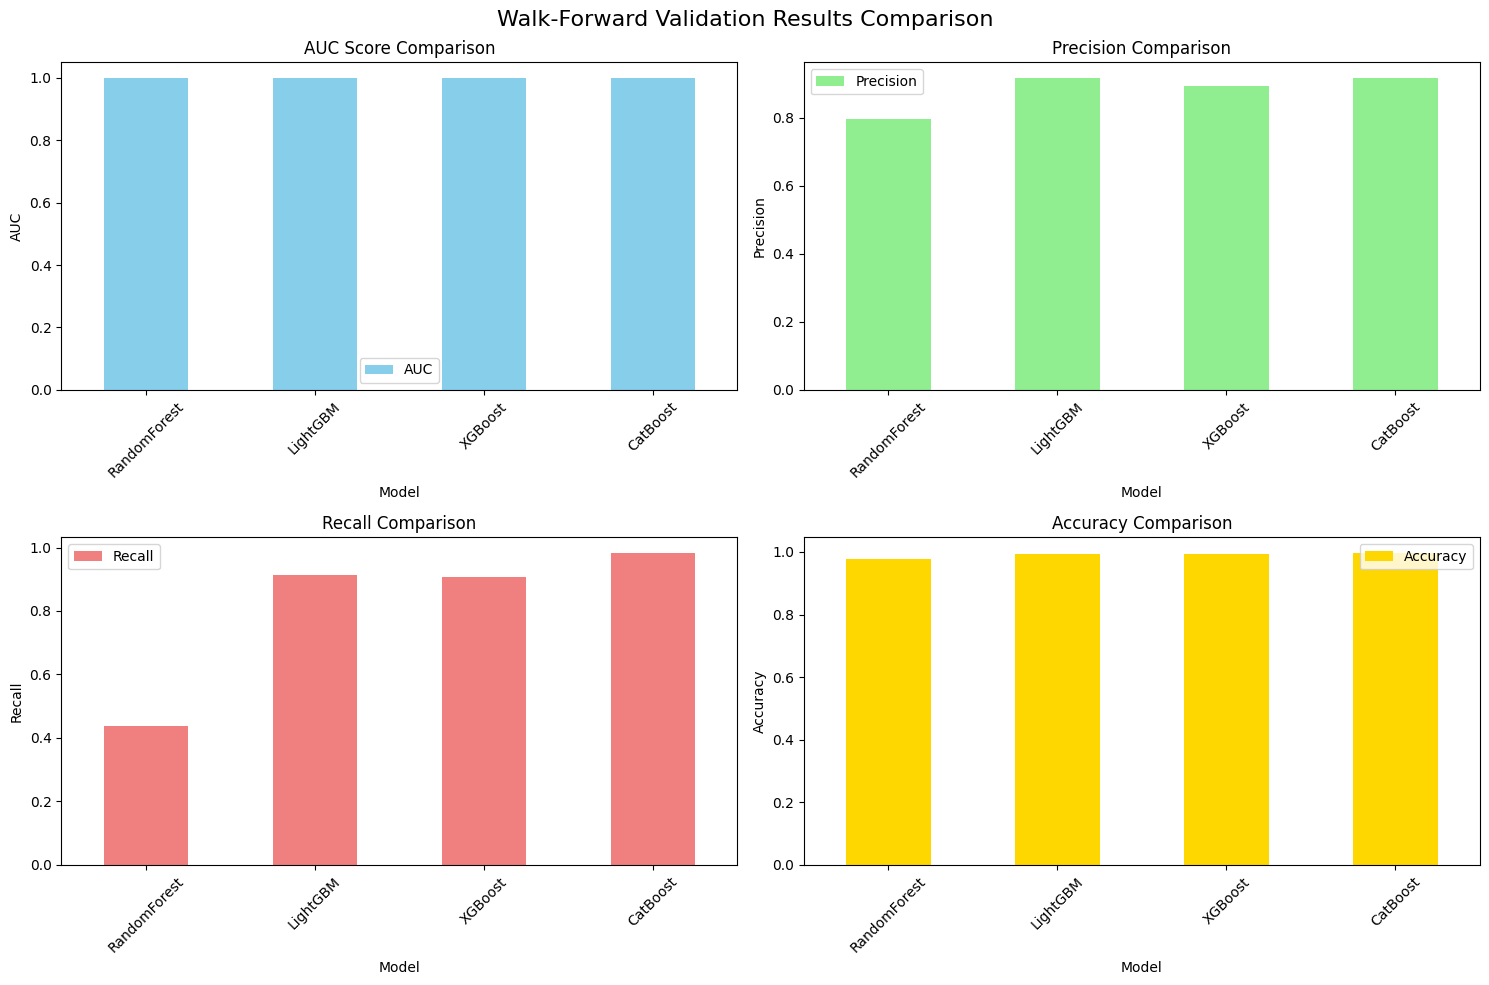

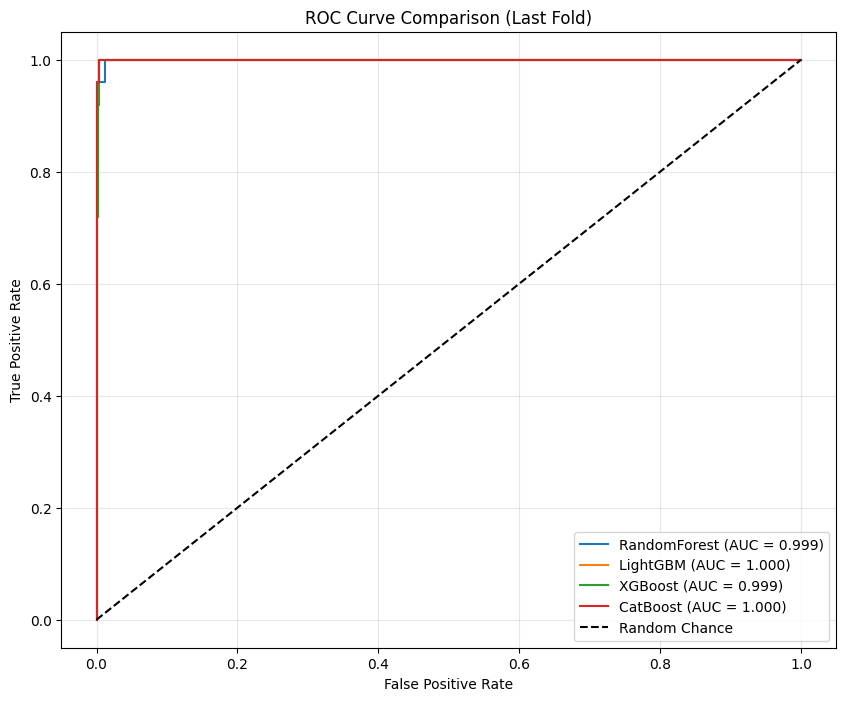

,Model,AUC,AUC_std,Precision,Precision_std,Recall,Recall_std,Accuracy,Accuracy_std
0,RandomForest,0.997763,0.002216,0.796667,0.398386,0.436192,0.322996,0.978067,0.013543
1,LightGBM,0.998131,0.003352,0.916377,0.083971,0.913730,0.087197,0.992872,0.006216
2,XGBoost,0.997772,0.003646,0.893178,0.091679,0.905954,0.072435,0.992872,0.005561
3,CatBoost,0.998994,0.001573,0.915098,0.064390,0.982902,0.023279,0.996984,0.001195


In [12]:
## Results Analysis and Visualization

import seaborn as sns
from matplotlib import pyplot as plt

def analyze_results(results):
    """Analyze and visualize walk-forward validation results"""
    
    print("\n" + "="*80)
    print("📊 WALK-FORWARD VALIDATION RESULTS SUMMARY")
    print("="*80)
    
    # Calculate average metrics
    summary_data = []
    for model_name, metrics in results.items():
        if len(metrics['auc']) > 0:  # Only if we have results
            avg_metrics = {
                'Model': model_name,
                'AUC': np.mean(metrics['auc']),
                'AUC_std': np.std(metrics['auc']),
                'Precision': np.mean(metrics['precision']),
                'Precision_std': np.std(metrics['precision']),
                'Recall': np.mean(metrics['recall']),
                'Recall_std': np.std(metrics['recall']),
                'Accuracy': np.mean(metrics['accuracy']),
                'Accuracy_std': np.std(metrics['accuracy'])
            }
            summary_data.append(avg_metrics)
            
            print(f"\n{model_name.upper()}:")
            print(f"  AUC:       {avg_metrics['AUC']:.4f} ± {avg_metrics['AUC_std']:.4f}")
            print(f"  PRECISION: {avg_metrics['Precision']:.4f} ± {avg_metrics['Precision_std']:.4f}")
            print(f"  RECALL:    {avg_metrics['Recall']:.4f} ± {avg_metrics['Recall_std']:.4f}")
            print(f"  ACCURACY:  {avg_metrics['Accuracy']:.4f} ± {avg_metrics['Accuracy_std']:.4f}")
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    if len(summary_df) > 0:
        # Find best models
        best_auc = summary_df.loc[summary_df['AUC'].idxmax(), 'Model']
        best_precision = summary_df.loc[summary_df['Precision'].idxmax(), 'Model']
        best_recall = summary_df.loc[summary_df['Recall'].idxmax(), 'Model']
        
        print(f"\n🏆 BEST PERFORMING MODELS:")
        print(f"   Best AUC:       {best_auc} ({summary_df['AUC'].max():.4f})")
        print(f"   Best Precision: {best_precision} ({summary_df['Precision'].max():.4f})")
        print(f"   Best Recall:    {best_recall} ({summary_df['Recall'].max():.4f})")
        
        # Visualization
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Walk-Forward Validation Results Comparison', fontsize=16)
        
        # AUC comparison
        summary_df.plot(x='Model', y='AUC', kind='bar', ax=axes[0,0], 
                       color='skyblue', yerr=summary_df['AUC_std'])
        axes[0,0].set_title('AUC Score Comparison')
        axes[0,0].set_ylabel('AUC')
        axes[0,0].tick_params(axis='x', rotation=45)
        
        # Precision comparison
        summary_df.plot(x='Model', y='Precision', kind='bar', ax=axes[0,1], 
                       color='lightgreen', yerr=summary_df['Precision_std'])
        axes[0,1].set_title('Precision Comparison')
        axes[0,1].set_ylabel('Precision')
        axes[0,1].tick_params(axis='x', rotation=45)
        
        # Recall comparison
        summary_df.plot(x='Model', y='Recall', kind='bar', ax=axes[1,0], 
                       color='lightcoral', yerr=summary_df['Recall_std'])
        axes[1,0].set_title('Recall Comparison')
        axes[1,0].set_ylabel('Recall')
        axes[1,0].tick_params(axis='x', rotation=45)
        
        # Accuracy comparison
        summary_df.plot(x='Model', y='Accuracy', kind='bar', ax=axes[1,1], 
                       color='gold', yerr=summary_df['Accuracy_std'])
        axes[1,1].set_title('Accuracy Comparison')
        axes[1,1].set_ylabel('Accuracy')
        axes[1,1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # ROC Curves for last fold
        if any(len(metrics['predictions']) > 0 for metrics in results.values()):
            plt.figure(figsize=(10, 8))
            
            for model_name, metrics in results.items():
                if len(metrics['predictions']) > 0:
                    # Use last fold for ROC curve
                    y_true_last = metrics['y_true'][-1]
                    y_pred_proba_last = metrics['predictions'][-1]
                    
                    if len(y_true_last.unique()) > 1:  # Only if both classes present
                        fpr, tpr, _ = roc_curve(y_true_last, y_pred_proba_last)
                        auc_score = roc_auc_score(y_true_last, y_pred_proba_last)
                        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')
            
            plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve Comparison (Last Fold)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
    return summary_df

# Analyze results
results_summary = analyze_results(validation_results)
results_summary

🔍 FEATURE IMPORTANCE ANALYSIS
   Using best model: CatBoost
Top 15 Most Important Features:
              feature  importance
60  hours_since_maint   25.274115
61  hours_since_error   23.654042
53    error_count_24h    6.325995
10      volt_mean_24h    4.998589
22     rotate_min_24h    4.536663
39  vibration_lag_24h    3.198948
44  vibration_mean_6h    2.526665
27    pressure_lag_6h    2.496634
32   pressure_min_24h    1.923421
12       volt_min_24h    1.890432
13       volt_max_24h    1.828450
30  pressure_mean_24h    1.349763
43  vibration_max_24h    1.331487
31   pressure_std_24h    1.304058
35    pressure_std_6h    1.280951


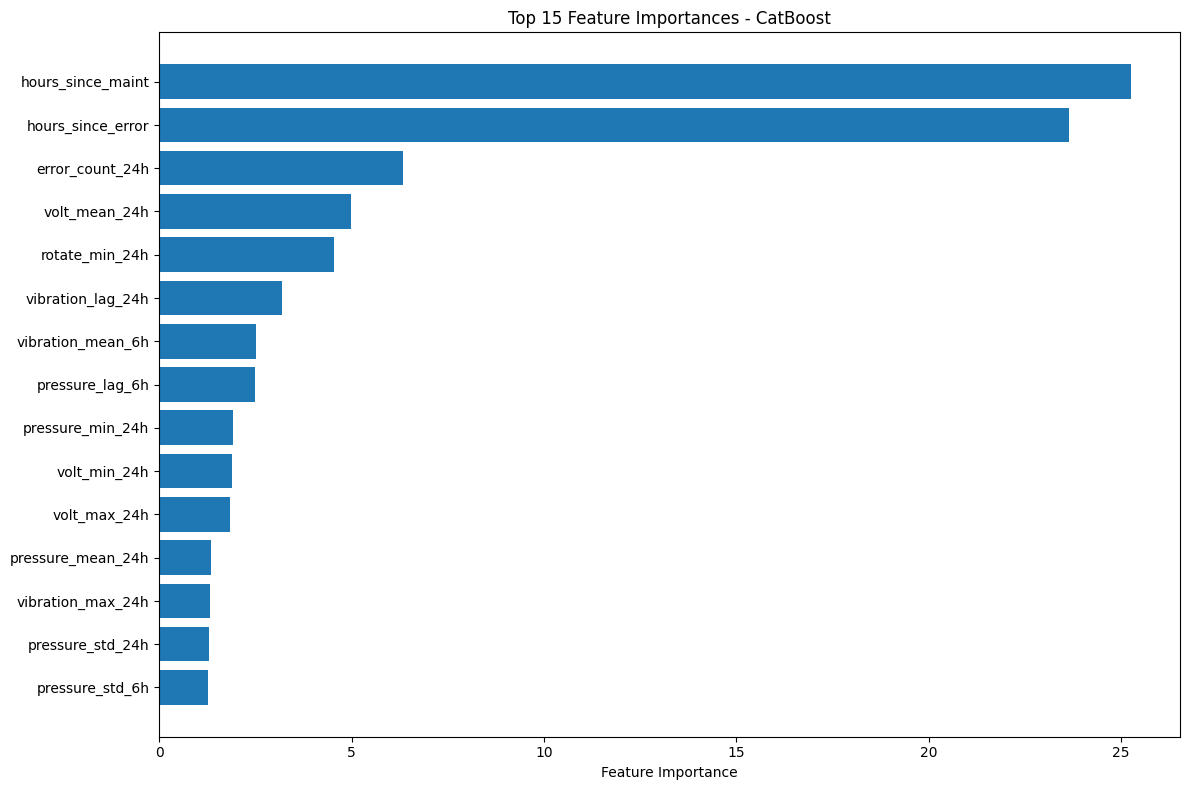

In [13]:
## Feature Importance Analysis

def analyze_feature_importance(df, feature_names, results):
    """Analyze feature importance from the best performing model"""
    
    if len(results_summary) > 0:
        # Get best model based on AUC
        best_model_name = results_summary.loc[results_summary['AUC'].idxmax(), 'Model']
        print(f"🔍 FEATURE IMPORTANCE ANALYSIS")
        print(f"   Using best model: {best_model_name}")
        print("=" * 50)
        
        # Retrain best model on full dataset for feature importance
        X = df[feature_names].fillna(0)
        y = df['target']
        
        # Configure best model
        if best_model_name == 'RandomForest':
            model = RandomForestClassifier(
                n_estimators=100, max_depth=10, min_samples_split=5,
                random_state=42, n_jobs=-1
            )
        elif best_model_name == 'LightGBM':
            model = LGBMClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                random_state=42, verbose=-1, force_col_wise=True
            )
        elif best_model_name == 'XGBoost':
            model = XGBClassifier(
                n_estimators=100, max_depth=6, learning_rate=0.1,
                random_state=42, eval_metric='logloss', verbosity=0
            )
        elif best_model_name == 'CatBoost':
            model = CatBoostClassifier(
                iterations=100, depth=6, learning_rate=0.1,
                random_state=42, verbose=False, allow_writing_files=False
            )
        
        # Train model
        model.fit(X, y)
        
        # Get feature importance
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_imp_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            print(f"Top 15 Most Important Features:")
            print(feature_imp_df.head(15))
            
            # Visualize top features
            plt.figure(figsize=(12, 8))
            top_features = feature_imp_df.head(15)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Feature Importance')
            plt.title(f'Top 15 Feature Importances - {best_model_name}')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
            
            return feature_imp_df
    
    return None

# Analyze feature importance
feature_importance_df = analyze_feature_importance(df_with_lags, feature_names, validation_results)











This implementation provides:

1. **Machine Selection**: Automatically finds the machine with the most failures for meaningful analysis
2. **Lag Feature Engineering**: Creates comprehensive lag features using only past data to prevent future data leakage
3. **Walk-Forward Validation**: Uses expanding window validation that simulates real deployment conditions
4. **Four ML Models**: Random Forest, LightGBM, XGBoost, and CatBoost with proper class balancing
5. **Comprehensive Analysis**: Results visualization, ROC curves, and feature importance analysis

The framework ensures:
- ✅ No future data leakage (lag features + proper target creation)
- ✅ Realistic deployment simulation (expanding window validation)
- ✅ Proper handling of class imbalance
- ✅ Comprehensive evaluation metrics
- ✅ Feature importance analysis for interpretability

Run these cells sequentially to get meaningful results with proper temporal validation!

<br> <br>

## SHAP


Implement a comprehensive SHAP analysis method for feature importance. Let me add this to your notebook:



🔍 SHAP FEATURE IMPORTANCE ANALYSIS
   Using best model: CatBoost
📊 Using random sample of 1,000 observations for SHAP analysis
   Sample target distribution: {0: 966, 1: 34}

🤖 Training CatBoost model...
🔬 Creating SHAP tree explainer...
⚡ Calculating SHAP values...
✅ SHAP analysis completed!
   SHAP values shape: (1000, 62)

📈 GENERATING SHAP VISUALIZATIONS
1️⃣ SHAP Summary Plot (Feature Importance)


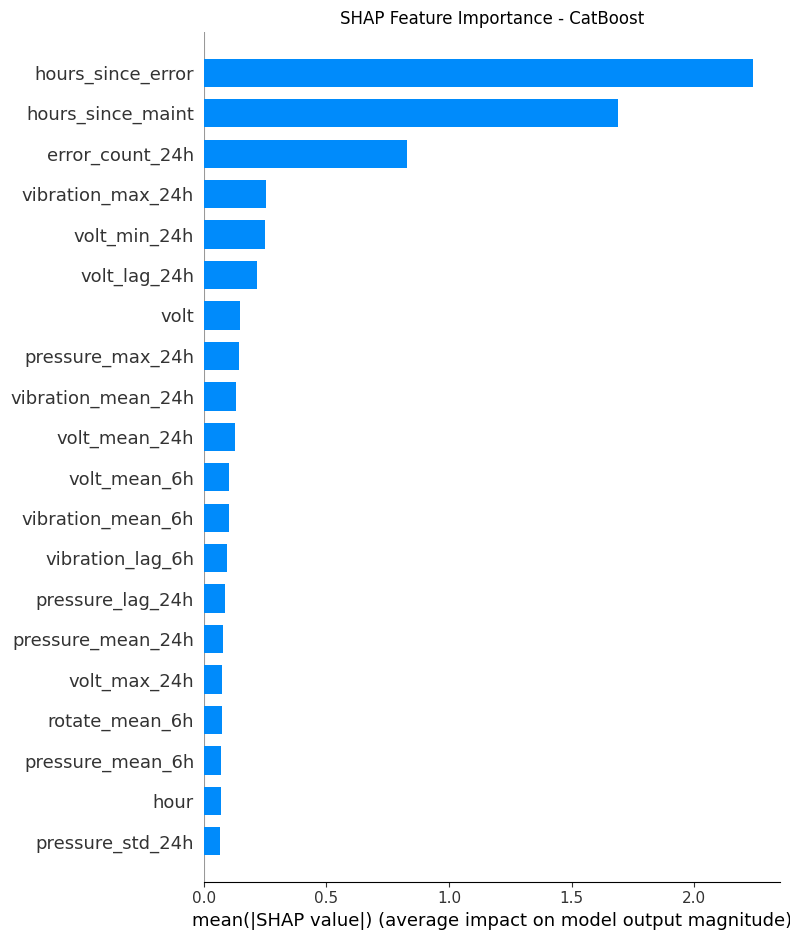

2️⃣ SHAP Summary Plot (Feature Effects)


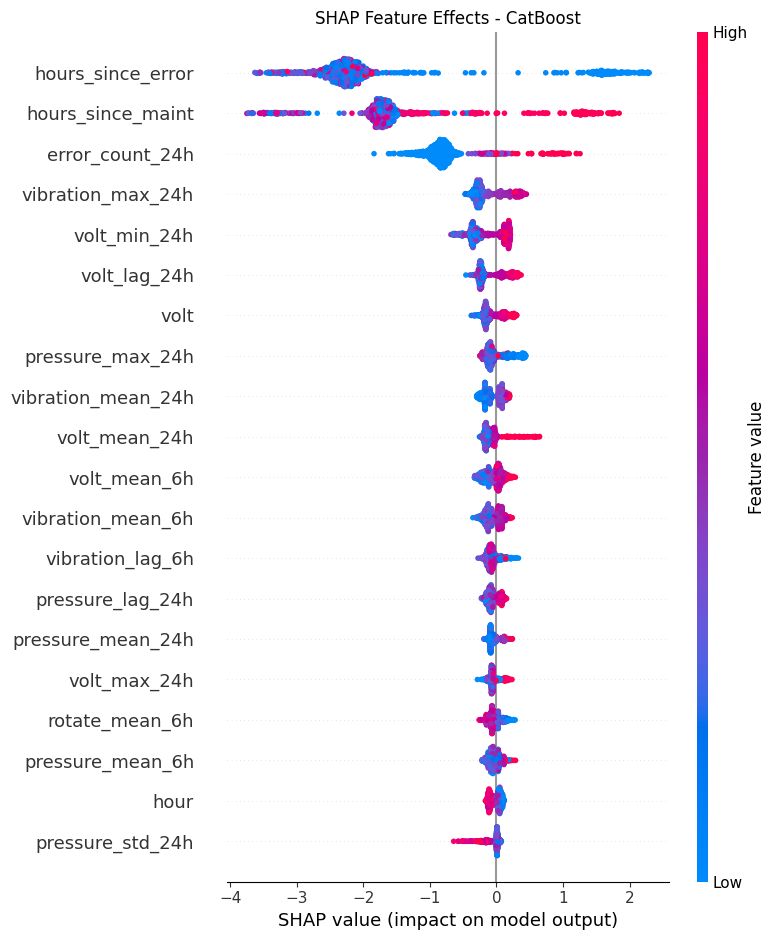

3️⃣ Top 20 Features by Mean Absolute SHAP Values:
           feature  mean_abs_shap
 hours_since_error       2.237352
 hours_since_maint       1.688575
   error_count_24h       0.829463
 vibration_max_24h       0.251596
      volt_min_24h       0.250955
      volt_lag_24h       0.216604
              volt       0.147780
  pressure_max_24h       0.143351
vibration_mean_24h       0.131610
     volt_mean_24h       0.126364
      volt_mean_6h       0.104065
 vibration_mean_6h       0.103878
  vibration_lag_6h       0.095643
  pressure_lag_24h       0.085422
 pressure_mean_24h       0.077679
      volt_max_24h       0.074962
    rotate_mean_6h       0.073005
  pressure_mean_6h       0.069970
              hour       0.067903
  pressure_std_24h       0.064723

4️⃣ Traditional vs SHAP Importance Comparison (Top 15):
           feature  traditional_importance  mean_abs_shap
 hours_since_error               28.279579       2.237352
 hours_since_maint               17.262123       1.688575
   er

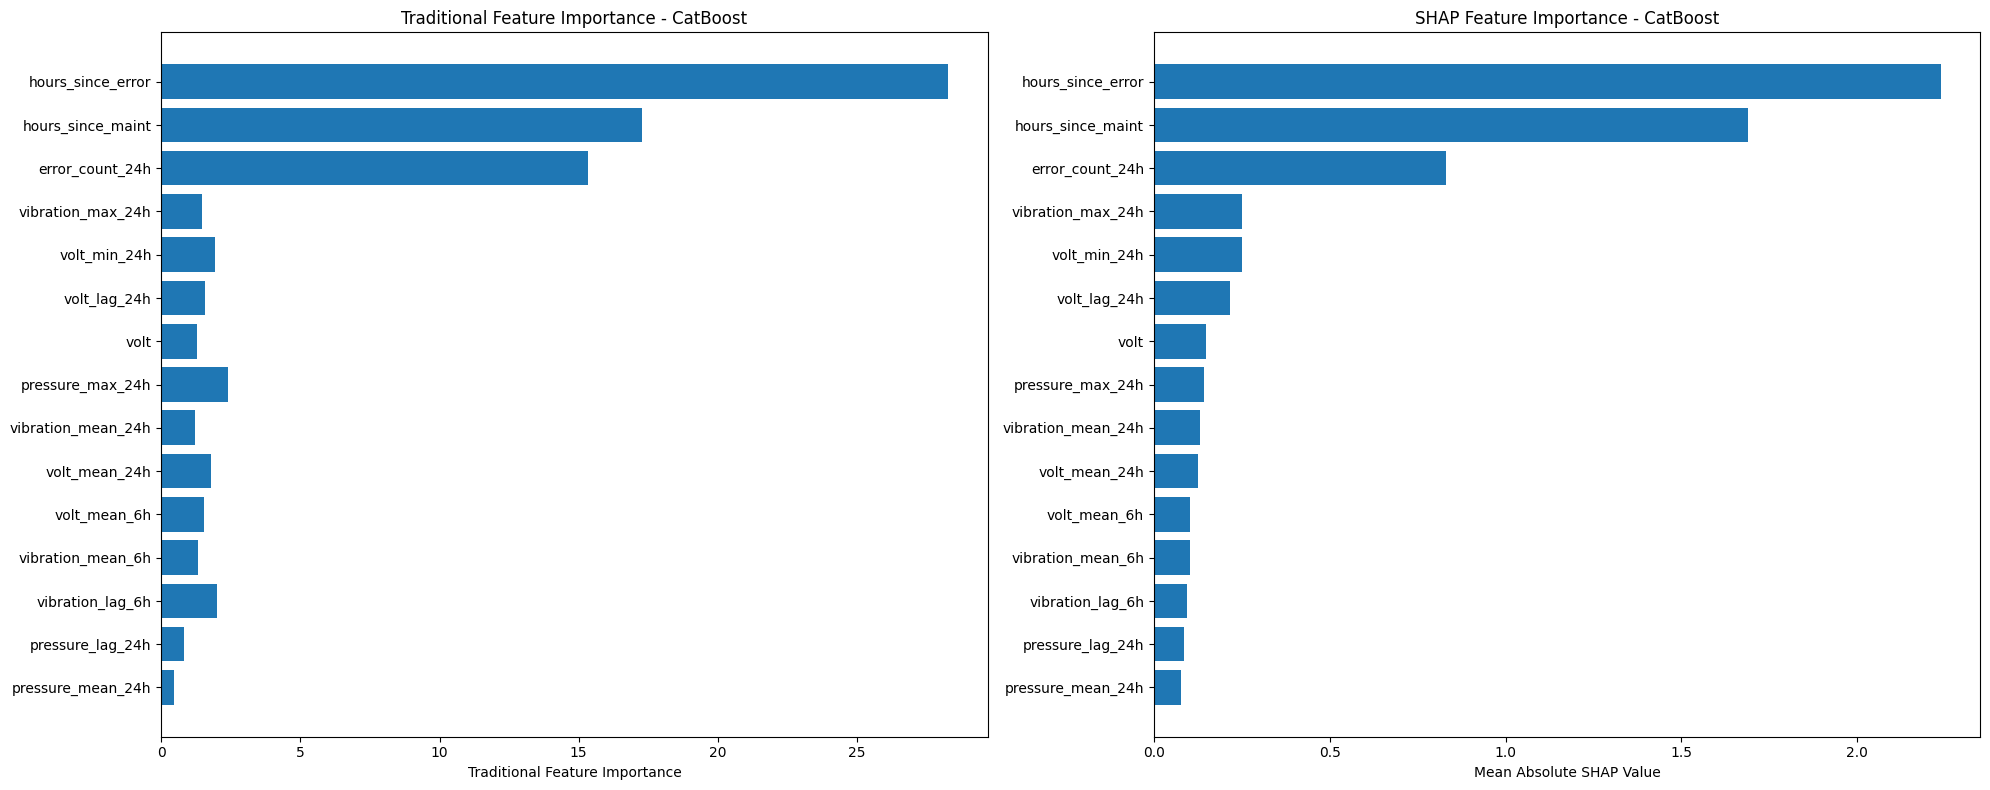


5️⃣ SHAP Waterfall Plots (Sample Predictions)


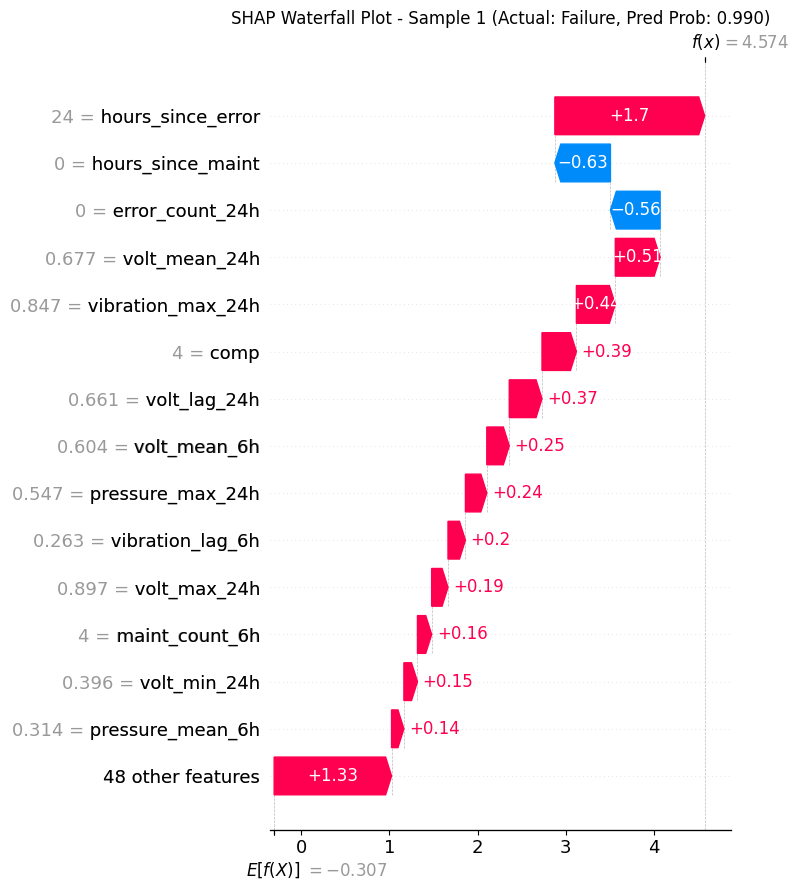

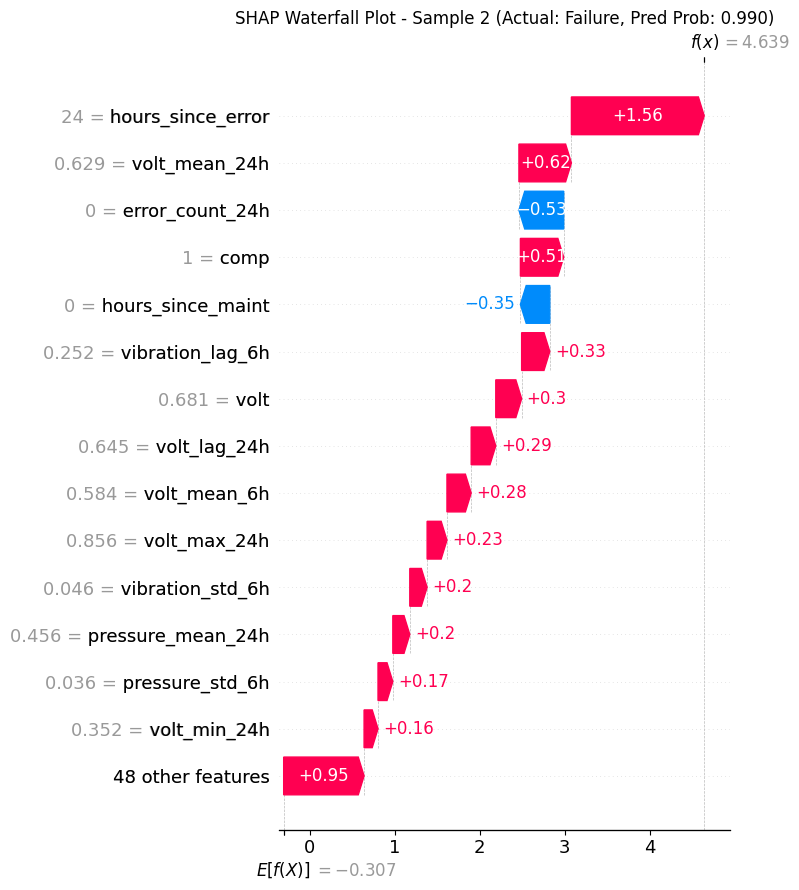

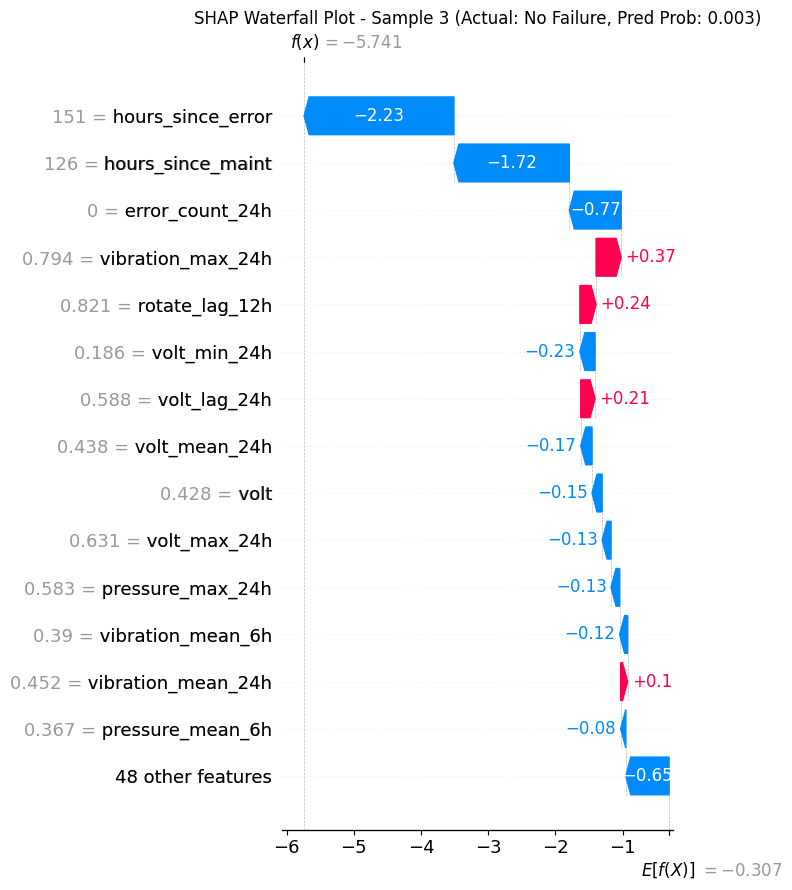

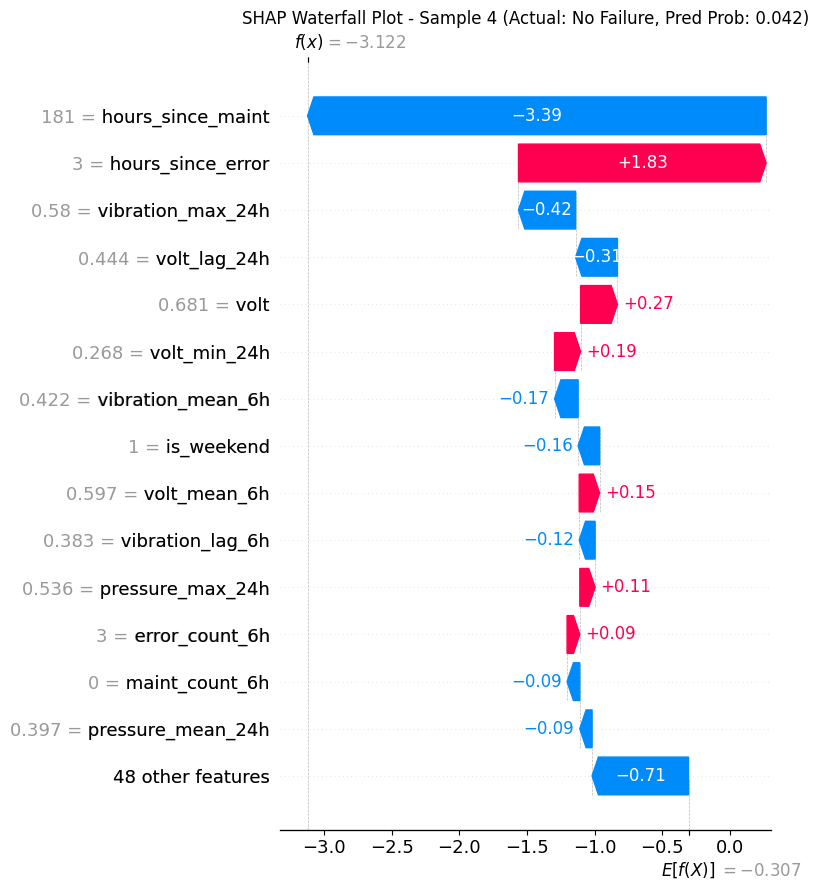


6️⃣ SHAP Importance by Feature Type:
   Feature Type Importance Summary:
     Time Features: 4.0713
     Rolling Statistics: 1.9655
     Count Features: 0.9048
     Lag Features: 0.8460
     Original Features: 0.2561


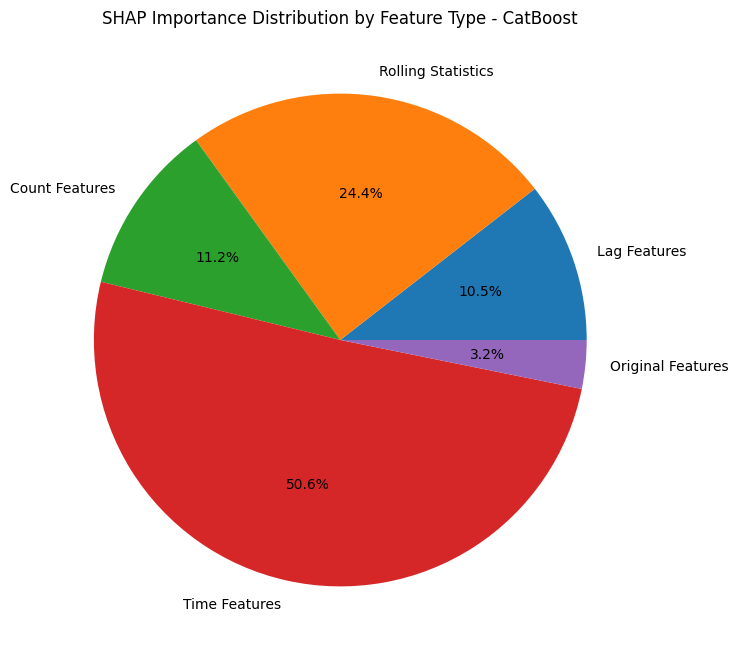


✅ SHAP Analysis completed successfully!
   📊 Most important feature: hours_since_error
   📈 Top feature type: Time Features


In [14]:
## Advanced Feature Importance Analysis using SHAP

import shap
import warnings
warnings.filterwarnings('ignore')

def analyze_feature_importance_with_shap(df, feature_names, results, results_summary, sample_size=1000):
    """
    Analyze feature importance using SHAP (SHapley Additive exPlanations)
    
    Args:
        df: DataFrame with features and target
        feature_names: List of feature column names
        results: Validation results dictionary
        results_summary: Summary DataFrame from validation
        sample_size: Number of samples to use for SHAP analysis (for computational efficiency)
    
    Returns:
        Dictionary containing SHAP values and analysis results
    """
    
    if len(results_summary) == 0:
        print("❌ No results available for SHAP analysis")
        return None
    
    # Get best model based on AUC
    best_model_name = results_summary.loc[results_summary['AUC'].idxmax(), 'Model']
    print(f"🔍 SHAP FEATURE IMPORTANCE ANALYSIS")
    print(f"   Using best model: {best_model_name}")
    print("=" * 60)
    
    # Prepare data
    X = df[feature_names].fillna(0)
    y = df['target']
    
    # Sample data for computational efficiency
    if len(X) > sample_size:
        sample_indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X.iloc[sample_indices]
        y_sample = y.iloc[sample_indices]
        print(f"📊 Using random sample of {sample_size:,} observations for SHAP analysis")
    else:
        X_sample = X
        y_sample = y
        print(f"📊 Using full dataset ({len(X):,} observations) for SHAP analysis")
    
    print(f"   Sample target distribution: {y_sample.value_counts().to_dict()}")
    
    # Configure and train best model
    print(f"\n🤖 Training {best_model_name} model...")
    
    if best_model_name == 'RandomForest':
        model = RandomForestClassifier(
            n_estimators=100, max_depth=10, min_samples_split=5,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
        explainer_type = 'tree'
    elif best_model_name == 'LightGBM':
        model = LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            class_weight='balanced', random_state=42, 
            verbose=-1, force_col_wise=True
        )
        explainer_type = 'tree'
    elif best_model_name == 'XGBoost':
        # Calculate scale_pos_weight for class imbalance
        pos_weight = (y_sample == 0).sum() / (y_sample == 1).sum() if (y_sample == 1).sum() > 0 else 1
        model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=pos_weight, random_state=42,
            eval_metric='logloss', verbosity=0
        )
        explainer_type = 'tree'
    elif best_model_name == 'CatBoost':
        pos_weight = (y_sample == 0).sum() / (y_sample == 1).sum() if (y_sample == 1).sum() > 0 else 1
        model = CatBoostClassifier(
            iterations=100, depth=6, learning_rate=0.1,
            class_weights=[1, pos_weight], random_state=42,
            verbose=False, allow_writing_files=False
        )
        explainer_type = 'tree'
    
    # Train model
    model.fit(X_sample, y_sample)
    
    # Create SHAP explainer
    print(f"🔬 Creating SHAP {explainer_type} explainer...")
    
    try:
        if explainer_type == 'tree':
            explainer = shap.TreeExplainer(model)
            # Use smaller background sample for tree explainer efficiency
            background_size = min(100, len(X_sample))
            background_indices = np.random.choice(len(X_sample), background_size, replace=False)
            X_background = X_sample.iloc[background_indices]
        else:
            # For other model types, use KernelExplainer with background sample
            background_size = min(50, len(X_sample))
            background_indices = np.random.choice(len(X_sample), background_size, replace=False)
            X_background = X_sample.iloc[background_indices]
            explainer = shap.KernelExplainer(model.predict_proba, X_background)
        
        # Calculate SHAP values
        print(f"⚡ Calculating SHAP values...")
        if explainer_type == 'tree':
            shap_values = explainer.shap_values(X_sample)
        else:
            shap_values = explainer.shap_values(X_sample)
        
        # Handle different SHAP output formats
        if isinstance(shap_values, list):
            # For binary classification, use positive class SHAP values
            shap_values_binary = shap_values[1]
        else:
            shap_values_binary = shap_values
        
        print(f"✅ SHAP analysis completed!")
        print(f"   SHAP values shape: {shap_values_binary.shape}")
        
    except Exception as e:
        print(f"❌ SHAP analysis failed: {str(e)}")
        print("   Falling back to traditional feature importance...")
        
        # Fallback to traditional feature importance
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_imp_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            plt.figure(figsize=(12, 8))
            top_features = feature_imp_df.head(20)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Feature Importance')
            plt.title(f'Top 20 Feature Importances - {best_model_name} (Fallback)')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()
            
            return {'feature_importance': feature_imp_df, 'shap_available': False}
        
        return None
    
    # SHAP Analysis and Visualizations
    print(f"\n📈 GENERATING SHAP VISUALIZATIONS")
    print("=" * 40)
    
    # 1. SHAP Summary Plot (Feature Importance)
    print("1️⃣ SHAP Summary Plot (Feature Importance)")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_binary, X_sample, plot_type="bar", show=False, max_display=20)
    plt.title(f'SHAP Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
    # 2. SHAP Summary Plot (Feature Effects)
    print("2️⃣ SHAP Summary Plot (Feature Effects)")
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values_binary, X_sample, show=False, max_display=20)
    plt.title(f'SHAP Feature Effects - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
    # 3. SHAP Mean Absolute Values (Global Feature Importance)
    mean_shap_values = np.abs(shap_values_binary).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_shap_values
    }).sort_values('mean_abs_shap', ascending=False)
    
    print("3️⃣ Top 20 Features by Mean Absolute SHAP Values:")
    print(shap_importance_df.head(20).to_string(index=False))
    
    # 4. Compare Traditional vs SHAP Feature Importance
    if hasattr(model, 'feature_importances_'):
        traditional_importance = pd.DataFrame({
            'feature': feature_names,
            'traditional_importance': model.feature_importances_
        })
        
        # Merge traditional and SHAP importance
        importance_comparison = traditional_importance.merge(
            shap_importance_df, on='feature'
        ).sort_values('mean_abs_shap', ascending=False)
        
        print("\n4️⃣ Traditional vs SHAP Importance Comparison (Top 15):")
        comparison_display = importance_comparison.head(15)[['feature', 'traditional_importance', 'mean_abs_shap']]
        print(comparison_display.to_string(index=False))
        
        # Visualization: Traditional vs SHAP Importance
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
        
        # Traditional importance
        top_traditional = importance_comparison.head(15)
        ax1.barh(range(len(top_traditional)), top_traditional['traditional_importance'])
        ax1.set_yticks(range(len(top_traditional)))
        ax1.set_yticklabels(top_traditional['feature'])
        ax1.set_xlabel('Traditional Feature Importance')
        ax1.set_title(f'Traditional Feature Importance - {best_model_name}')
        ax1.invert_yaxis()
        
        # SHAP importance
        ax2.barh(range(len(top_traditional)), top_traditional['mean_abs_shap'])
        ax2.set_yticks(range(len(top_traditional)))
        ax2.set_yticklabels(top_traditional['feature'])
        ax2.set_xlabel('Mean Absolute SHAP Value')
        ax2.set_title(f'SHAP Feature Importance - {best_model_name}')
        ax2.invert_yaxis()
        
        plt.tight_layout()
        plt.show()
    
    # 5. SHAP Waterfall Plot for a Few Examples
    print("\n5️⃣ SHAP Waterfall Plots (Sample Predictions)")
    
    # Show waterfall plots for a few interesting examples
    failure_indices = np.where(y_sample == 1)[0]
    no_failure_indices = np.where(y_sample == 0)[0]
    
    sample_indices = []
    if len(failure_indices) > 0:
        sample_indices.extend(np.random.choice(failure_indices, min(2, len(failure_indices)), replace=False))
    if len(no_failure_indices) > 0:
        sample_indices.extend(np.random.choice(no_failure_indices, min(2, len(no_failure_indices)), replace=False))
    
    for i, idx in enumerate(sample_indices):
        plt.figure(figsize=(12, 6))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values_binary[idx], 
                base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
                data=X_sample.iloc[idx],
                feature_names=feature_names
            ),
            max_display=15,
            show=False
        )
        actual_label = "Failure" if y_sample.iloc[idx] == 1 else "No Failure"
        predicted_proba = model.predict_proba(X_sample.iloc[[idx]])[0, 1]
        plt.title(f'SHAP Waterfall Plot - Sample {i+1} (Actual: {actual_label}, Pred Prob: {predicted_proba:.3f})')
        plt.tight_layout()
        plt.show()
    
    # 6. Feature Type Analysis
    print("\n6️⃣ SHAP Importance by Feature Type:")
    
    # Categorize features
    lag_features = shap_importance_df[shap_importance_df['feature'].str.contains('_lag_')]
    rolling_features = shap_importance_df[shap_importance_df['feature'].str.contains('_mean_|_std_|_min_|_max_')]
    count_features = shap_importance_df[shap_importance_df['feature'].str.contains('_count_')]
    time_features = shap_importance_df[shap_importance_df['feature'].str.contains('hour|day_of_week|weekend|working')]
    original_features = shap_importance_df[
        ~shap_importance_df['feature'].str.contains('_lag_|_mean_|_std_|_min_|_max_|_count_|hour|day_of_week|weekend|working')
    ]
    
    feature_type_importance = {
        'Lag Features': lag_features['mean_abs_shap'].sum(),
        'Rolling Statistics': rolling_features['mean_abs_shap'].sum(),
        'Count Features': count_features['mean_abs_shap'].sum(),
        'Time Features': time_features['mean_abs_shap'].sum(),
        'Original Features': original_features['mean_abs_shap'].sum()
    }
    
    print("   Feature Type Importance Summary:")
    for feature_type, importance in sorted(feature_type_importance.items(), key=lambda x: x[1], reverse=True):
        print(f"     {feature_type}: {importance:.4f}")
    
    # Pie chart of feature type importance
    plt.figure(figsize=(10, 8))
    plt.pie(feature_type_importance.values(), labels=feature_type_importance.keys(), autopct='%1.1f%%')
    plt.title(f'SHAP Importance Distribution by Feature Type - {best_model_name}')
    plt.show()
    
    # Return results
    results_dict = {
        'model_name': best_model_name,
        'shap_values': shap_values_binary,
        'shap_importance': shap_importance_df,
        'feature_type_importance': feature_type_importance,
        'X_sample': X_sample,
        'y_sample': y_sample,
        'explainer': explainer,
        'shap_available': True
    }
    
    if hasattr(model, 'feature_importances_'):
        results_dict['importance_comparison'] = importance_comparison
    
    print(f"\n✅ SHAP Analysis completed successfully!")
    print(f"   📊 Most important feature: {shap_importance_df.iloc[0]['feature']}")
    print(f"   📈 Top feature type: {max(feature_type_importance.items(), key=lambda x: x[1])[0]}")
    
    return results_dict

# Install SHAP if not already installed
try:
    import shap
except ImportError:
    print("Installing SHAP...")
    import subprocess
    subprocess.check_call(["pip", "install", "shap"])
    import shap

# Run SHAP analysis
shap_results = analyze_feature_importance_with_shap(
    df_with_lags, feature_names, validation_results, results_summary, sample_size=1000
)



This comprehensive SHAP implementation provides:

## 🔍 **SHAP Analysis Features:**

1. **Multiple Visualizations:**
   - SHAP summary plot (bar chart for importance)
   - SHAP summary plot (bee swarm for feature effects)
   - Waterfall plots for individual predictions
   - Feature type importance pie chart

2. **Comparison Analysis:**
   - Traditional vs SHAP feature importance
   - Side-by-side visualization
   - Feature type categorization (lag, rolling, count, time, original)

3. **Efficiency Optimizations:**
   - Sampling for large datasets
   - Tree explainer for tree-based models
   - Background dataset optimization

4. **Comprehensive Output:**
   - Top features by SHAP importance
   - Feature type importance distribution
   - Individual prediction explanations
   - Comparison with traditional methods

## 🎯 **Key Benefits:**

- **Model-Agnostic:** Works with all your models (RF, XGB, LightGBM, CatBoost)
- **Local & Global:** Shows both individual prediction explanations and global feature importance
- **Feature Interactions:** SHAP captures feature interactions that traditional importance misses
- **Additive:** SHAP values sum to the difference between prediction and baseline

The method automatically handles the best performing model from your validation results and provides rich insights into which lag features, rolling statistics, and temporal patterns are most important for predicting failures!

In [15]:
df_with_lags["failure"].value_counts()

0    8731
3       7
1       7
4       6
2       6
Name: failure, dtype: int64

In [16]:
df_with_lags.head()

,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,binary_failure,target,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-01 06:00:00,0.303137,0.604476,0.271993,0.621000,0,0,0,0,0,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
1,2015-01-01 07:00:00,0.455312,0.635538,0.480756,0.645421,0,0,0,0,0,...,0.0,0.0,0.0,0.0,7,3,0,0,1,1
2,2015-01-01 08:00:00,0.449470,0.540973,0.427196,0.356126,0,0,0,0,0,...,0.0,0.0,0.0,0.0,8,3,0,1,2,2
3,2015-01-01 09:00:00,0.408248,0.687752,0.378658,0.254123,0,0,0,0,0,...,0.0,0.0,0.0,0.0,9,3,0,1,3,3
4,2015-01-01 10:00:00,0.486041,0.518746,0.454206,0.351050,0,0,0,0,0,...,0.0,0.0,0.0,0.0,10,3,0,1,4,4


<br> <br> <br>

## SHAP on row/rows

- Create a new SHAP method specifically for analyzing individual failure samples. 

- This method will take sample rows and identify the most important features for those specific predictions.



In [17]:
## SHAP Analysis for Specific Failure Samples

def analyze_failure_samples_with_shap(sample_df, target_col='target', top_n_features=10):
    """
    Analyze specific failure samples using SHAP to identify top contributing features.
    
    Args:
        sample_df: DataFrame containing one or more sample rows to analyze
        target_col: Name of the target column (default: 'target')
        top_n_features: Number of top important features to return (default: 10)
    
    Returns:
        Dictionary containing SHAP analysis results for the sample(s)
    """
    
    print(f"🔍 SHAP ANALYSIS FOR FAILURE SAMPLES")
    print("=" * 50)
    print(f"📊 Analyzing {len(sample_df)} sample(s)")
    print(f"🎯 Target column: '{target_col}'")
    print(f"📈 Top {top_n_features} features requested")
    
    # Validate inputs
    if len(sample_df) == 0:
        print("❌ ERROR: Empty sample dataframe provided")
        return None
    
    if target_col not in sample_df.columns:
        print(f"❌ ERROR: Target column '{target_col}' not found in sample dataframe")
        return None
    
    # Check if we have trained models from previous validation
    if 'validation_results' not in globals() or validation_results is None:
        print("❌ ERROR: No trained models found. Please run walk-forward validation first.")
        return None
    
    if 'results_summary' not in globals() or len(results_summary) == 0:
        print("❌ ERROR: No model results available. Please run model analysis first.")
        return None
    
    # Get best model from previous analysis
    best_model_name = results_summary.loc[results_summary['AUC'].idxmax(), 'Model']
    print(f"🤖 Using best performing model: {best_model_name}")
    
    # Prepare feature columns (exclude metadata columns)
    exclude_cols = ['datetime', 'machineID', 'failure', 'binary_failure', target_col]
    feature_cols = [col for col in sample_df.columns if col not in exclude_cols]
    
    if len(feature_cols) == 0:
        print("❌ ERROR: No feature columns found after excluding metadata")
        return None
    
    print(f"📋 Using {len(feature_cols)} features for analysis")
    
    # Extract features from sample
    X_sample = sample_df[feature_cols].fillna(0)
    y_sample = sample_df[target_col]
    
    print(f"   Sample target values: {y_sample.tolist()}")
    
    # Prepare training data for model (use full dataset if available)
    if 'df_with_lags' in globals():
        X_train = df_with_lags[feature_cols].fillna(0)
        y_train = df_with_lags[target_col]
        print(f"📚 Using full training dataset: {len(X_train):,} samples")
    else:
        print("⚠️  WARNING: Full dataset not available, using sample for training")
        X_train = X_sample
        y_train = y_sample
    
    # Configure and train the best model
    print(f"\n🔧 Configuring {best_model_name} model...")
    
    if best_model_name == 'RandomForest':
        model = RandomForestClassifier(
            n_estimators=100, max_depth=10, min_samples_split=5,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
    elif best_model_name == 'LightGBM':
        model = LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            class_weight='balanced', random_state=42, 
            verbose=-1, force_col_wise=True
        )
    elif best_model_name == 'XGBoost':
        # Calculate class balance
        pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1
        model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=pos_weight, random_state=42,
            eval_metric='logloss', verbosity=0
        )
    elif best_model_name == 'CatBoost':
        pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1
        model = CatBoostClassifier(
            iterations=100, depth=6, learning_rate=0.1,
            class_weights=[1, pos_weight], random_state=42,
            verbose=False, allow_writing_files=False
        )
    
    # Train the model
    print("🏋️ Training model...")
    model.fit(X_train, y_train)
    
    # Make predictions for the samples
    sample_predictions = model.predict_proba(X_sample)[:, 1]
    sample_classes = model.predict(X_sample)
    
    print(f"🎯 Sample predictions:")
    for i, (actual, pred_prob, pred_class) in enumerate(zip(y_sample, sample_predictions, sample_classes)):
        print(f"   Sample {i+1}: Actual={actual}, Predicted_Prob={pred_prob:.4f}, Predicted_Class={pred_class}")
    
    # Create SHAP explainer
    print(f"\n🔬 Creating SHAP explainer...")
    
    try:
        # Use TreeExplainer for tree-based models
        explainer = shap.TreeExplainer(model)
        
        # Calculate SHAP values for the samples
        print(f"⚡ Calculating SHAP values for {len(X_sample)} sample(s)...")
        shap_values = explainer.shap_values(X_sample)
        
        # Handle different SHAP output formats
        if isinstance(shap_values, list):
            # For binary classification, use positive class SHAP values
            shap_values_binary = shap_values[1]
        else:
            shap_values_binary = shap_values
        
        print(f"✅ SHAP values calculated successfully!")
        print(f"   SHAP values shape: {shap_values_binary.shape}")
        
    except Exception as e:
        print(f"❌ SHAP analysis failed: {str(e)}")
        return None
    
    # Analyze results for each sample
    sample_results = []
    
    for i in range(len(X_sample)):
        print(f"\n📊 ANALYSIS FOR SAMPLE {i+1}")
        print("-" * 30)
        
        # Get SHAP values for this sample
        sample_shap = shap_values_binary[i]
        
        # Create feature importance dataframe for this sample
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'shap_value': sample_shap,
            'abs_shap_value': np.abs(sample_shap),
            'feature_value': X_sample.iloc[i].values
        }).sort_values('abs_shap_value', ascending=False)
        
        # Get top N features
        top_features = feature_importance.head(top_n_features)
        
        print(f"🏆 Top {top_n_features} Most Important Features:")
        print(top_features[['feature', 'shap_value', 'feature_value']].to_string(index=False))
        
        # Visualizations for this sample
        print(f"\n📈 Generating visualizations for Sample {i+1}...")
        
        # 1. Waterfall plot
        plt.figure(figsize=(12, 8))
        shap.waterfall_plot(
            shap.Explanation(
                values=sample_shap, 
                base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
                data=X_sample.iloc[i],
                feature_names=feature_cols
            ),
            max_display=top_n_features,
            show=False
        )
        actual_label = "Failure" if y_sample.iloc[i] == 1 else "No Failure"
        pred_prob = sample_predictions[i]
        plt.title(f'SHAP Waterfall Plot - Sample {i+1}\n(Actual: {actual_label}, Predicted Prob: {pred_prob:.3f})')
        plt.tight_layout()
        plt.show()
        
        # 2. Force plot (as bar chart)
        plt.figure(figsize=(14, 8))
        colors = ['red' if val < 0 else 'green' for val in top_features['shap_value']]
        plt.barh(range(len(top_features)), top_features['shap_value'], color=colors)
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('SHAP Value (Impact on Prediction)')
        plt.title(f'Feature Contributions - Sample {i+1}\n(Positive = Increases Failure Risk, Negative = Decreases Failure Risk)')
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.gca().invert_yaxis()
        
        # Add feature values as text
        for idx, (shap_val, feat_val) in enumerate(zip(top_features['shap_value'], top_features['feature_value'])):
            plt.text(shap_val + (0.001 if shap_val >= 0 else -0.001), idx, 
                    f'val={feat_val:.3f}', ha='left' if shap_val >= 0 else 'right', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # 3. Feature type analysis for this sample
        print(f"\n🔍 Feature Type Analysis for Sample {i+1}:")
        
        # Categorize top features
        lag_features = top_features[top_features['feature'].str.contains('_lag_')]
        rolling_features = top_features[top_features['feature'].str.contains('_mean_|_std_|_min_|_max_')]
        count_features = top_features[top_features['feature'].str.contains('_count_')]
        time_features = top_features[top_features['feature'].str.contains('hour|day_of_week|weekend|working')]
        original_features = top_features[
            ~top_features['feature'].str.contains('_lag_|_mean_|_std_|_min_|_max_|_count_|hour|day_of_week|weekend|working')
        ]
        
        feature_type_importance = {
            'Lag Features': lag_features['abs_shap_value'].sum(),
            'Rolling Statistics': rolling_features['abs_shap_value'].sum(),
            'Count Features': count_features['abs_shap_value'].sum(),
            'Time Features': time_features['abs_shap_value'].sum(),
            'Original Features': original_features['abs_shap_value'].sum()
        }
        
        print("   Feature Type Contributions:")
        for feature_type, importance in sorted(feature_type_importance.items(), key=lambda x: x[1], reverse=True):
            if importance > 0:
                print(f"     {feature_type}: {importance:.4f}")
        
        # Store results for this sample
        sample_results.append({
            'sample_index': i,
            'actual_target': y_sample.iloc[i],
            'predicted_probability': sample_predictions[i],
            'predicted_class': sample_classes[i],
            'top_features': top_features,
            'feature_type_importance': feature_type_importance,
            'shap_values': sample_shap
        })
    
    # Summary across all samples
    if len(sample_results) > 1:
        print(f"\n🎯 SUMMARY ACROSS ALL {len(sample_results)} SAMPLES")
        print("=" * 40)
        
        # Aggregate feature importance across samples
        all_features_importance = {}
        for result in sample_results:
            for _, row in result['top_features'].iterrows():
                feature = row['feature']
                if feature not in all_features_importance:
                    all_features_importance[feature] = []
                all_features_importance[feature].append(row['abs_shap_value'])
        
        # Calculate average importance
        avg_importance = {feat: np.mean(values) for feat, values in all_features_importance.items()}
        overall_top_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)[:top_n_features]
        
        print(f"🏆 Top {top_n_features} Features Across All Samples (Average Importance):")
        for i, (feature, avg_imp) in enumerate(overall_top_features, 1):
            print(f"   {i:2d}. {feature:30s} : {avg_imp:.4f}")
    
    # Return comprehensive results
    return {
        'model_name': best_model_name,
        'sample_results': sample_results,
        'feature_columns': feature_cols,
        'top_n_features': top_n_features,
        'overall_top_features': overall_top_features if len(sample_results) > 1 else sample_results[0]['top_features'],
        'explainer': explainer,
        'model': model
    }

print("✅ SHAP failure sample analysis method created!")
print("📝 Usage: analyze_failure_samples_with_shap(sample_df, target_col='target', top_n_features=10)")

✅ SHAP failure sample analysis method created!
📝 Usage: analyze_failure_samples_with_shap(sample_df, target_col='target', top_n_features=10)




Now let's create a helper function to easily extract failure samples from your dataset:



In [18]:
## Helper Function to Extract Failure Samples

def get_failure_samples(df, target_col='target', n_samples=3, sample_type='random'):
    """
    Extract failure samples from the dataset for SHAP analysis.
    
    Args:
        df: Main dataframe with features and target
        target_col: Name of the target column
        n_samples: Number of failure samples to extract
        sample_type: Type of sampling ('random', 'recent', 'diverse')
    
    Returns:
        DataFrame containing failure samples
    """
    
    print(f"🔍 EXTRACTING FAILURE SAMPLES")
    print("=" * 35)
    
    # Get failure samples (where target = 1)
    failure_samples = df[df[target_col] == 1].copy()
    
    if len(failure_samples) == 0:
        print("❌ No failure samples found in the dataset")
        return pd.DataFrame()
    
    print(f"📊 Found {len(failure_samples):,} failure samples in dataset")
    
    if len(failure_samples) <= n_samples:
        print(f"📋 Returning all {len(failure_samples)} available failure samples")
        return failure_samples
    
    # Different sampling strategies
    if sample_type == 'random':
        print(f"🎲 Randomly sampling {n_samples} failure cases")
        selected_samples = failure_samples.sample(n=n_samples, random_state=42)
        
    elif sample_type == 'recent':
        print(f"📅 Selecting {n_samples} most recent failure cases")
        if 'datetime' in failure_samples.columns:
            selected_samples = failure_samples.sort_values('datetime', ascending=False).head(n_samples)
        else:
            print("⚠️  No datetime column found, using last rows instead")
            selected_samples = failure_samples.tail(n_samples)
            
    elif sample_type == 'diverse':
        print(f"🌈 Selecting {n_samples} diverse failure cases")
        # Try to get diverse samples based on feature variance
        if len(failure_samples.select_dtypes(include=[np.number]).columns) > 0:
            # Use k-means clustering to get diverse samples
            from sklearn.cluster import KMeans
            
            numeric_cols = failure_samples.select_dtypes(include=[np.number]).columns
            X_numeric = failure_samples[numeric_cols].fillna(0)
            
            # Use min of n_samples or available samples for clustering
            n_clusters = min(n_samples, len(failure_samples))
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            clusters = kmeans.fit_predict(X_numeric)
            
            # Select one sample from each cluster
            selected_indices = []
            for cluster_id in range(n_clusters):
                cluster_samples = failure_samples[clusters == cluster_id]
                if len(cluster_samples) > 0:
                    # Select sample closest to cluster center
                    cluster_center = kmeans.cluster_centers_[cluster_id]
                    cluster_X = X_numeric[clusters == cluster_id]
                    distances = ((cluster_X - cluster_center) ** 2).sum(axis=1)
                    closest_idx = cluster_X.index[distances.argmin()]
                    selected_indices.append(closest_idx)
            
            selected_samples = failure_samples.loc[selected_indices[:n_samples]]
        else:
            print("⚠️  No numeric columns for diversity sampling, using random instead")
            selected_samples = failure_samples.sample(n=n_samples, random_state=42)
    
    else:
        print(f"⚠️  Unknown sample_type '{sample_type}', using random sampling")
        selected_samples = failure_samples.sample(n=n_samples, random_state=42)
    
    print(f"✅ Selected {len(selected_samples)} failure samples")
    
    # Display sample info
    if 'datetime' in selected_samples.columns:
        print(f"📅 Sample date range: {selected_samples['datetime'].min()} to {selected_samples['datetime'].max()}")
    
    return selected_samples

print("✅ Helper function for extracting failure samples created!")
print("📝 Usage: get_failure_samples(df, target_col='target', n_samples=3, sample_type='random')")

✅ Helper function for extracting failure samples created!
📝 Usage: get_failure_samples(df, target_col='target', n_samples=3, sample_type='random')




Now let's create an example usage:



<br> <br> <br>

## SHAP on several data rows

Here we choose several data from dataframe and calculate the shap on all of them

🔥 EXAMPLE 1: Analyzing All Failure Samples Together
🔍 EXTRACTING FAILURE SAMPLES
📊 Found 348 failure samples in dataset
🎲 Randomly sampling 20 failure cases
✅ Selected 20 failure samples
📅 Sample date range: 2015-02-13 21:00:00 to 2015-11-25 09:00:00


,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,binary_failure,target,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
5371,2015-08-12 12:00:00,0.815078,0.436615,0.417999,0.485498,0,0,0,0,1,...,0.0,1.0,0.0,0.0,12,2,0,1,342,6
2852,2015-04-29 22:00:00,0.496063,0.434034,0.514113,0.720875,0,0,0,0,1,...,0.0,10.0,0.0,0.0,22,2,0,0,354,16
7186,2015-10-26 21:00:00,0.379309,0.205239,0.376477,0.448534,0,0,0,0,1,...,0.0,8.0,0.0,0.0,21,0,0,0,352,15
5384,2015-08-13 01:00:00,0.636473,0.613600,0.216967,0.365577,0,0,0,0,1,...,0.0,1.0,0.0,0.0,1,3,0,0,355,19
3577,2015-05-30 00:00:00,0.611469,0.639273,0.350072,0.313168,0,0,0,0,1,...,0.0,4.0,0.0,0.0,0,5,1,0,354,18
2862,2015-04-30 06:00:00,0.310040,0.367214,0.269911,0.583013,0,4,2,1,1,...,0.0,0.0,8.0,8.0,6,3,0,0,0,26
4287,2015-06-28 12:00:00,0.476934,0.632200,0.335218,0.628078,0,0,0,0,1,...,0.0,6.0,0.0,0.0,12,6,1,1,343,6
5004,2015-07-28 06:00:00,0.572254,0.591582,0.645159,0.536609,4,0,0,0,1,...,4.0,4.0,0.0,0.0,6,1,0,0,336,0
5737,2015-08-27 16:00:00,0.606424,0.334809,0.273063,0.525189,0,0,0,0,1,...,0.0,5.0,0.0,0.0,16,3,0,1,347,10
3563,2015-05-29 10:00:00,0.380945,0.549756,0.612172,0.324163,0,0,0,0,1,...,4.0,4.0,0.0,0.0,10,4,0,1,340,4



🔬 Calculating SHAP for all 20 samples at once...
🤖 Using best performing model: CatBoost
⚡ Calculating SHAP values for all 20 samples...
✅ SHAP values calculated! Shape: (20, 62)

🏆 Top 15 Most Important Features (across all 20 samples):
          feature  mean_abs_shap
hours_since_error       2.586303
hours_since_maint       2.325984
  error_count_24h       1.786300
pressure_mean_24h       0.296407
     volt_min_24h       0.278190
 pressure_min_24h       0.262213
vibration_mean_6h       0.215022
  rotate_mean_24h       0.183684
     volt_mean_6h       0.181301
vibration_max_24h       0.179226
     volt_max_24h       0.167231
vibration_min_24h       0.159395
vibration_lag_24h       0.151779
           rotate       0.141400
        vibration       0.135650


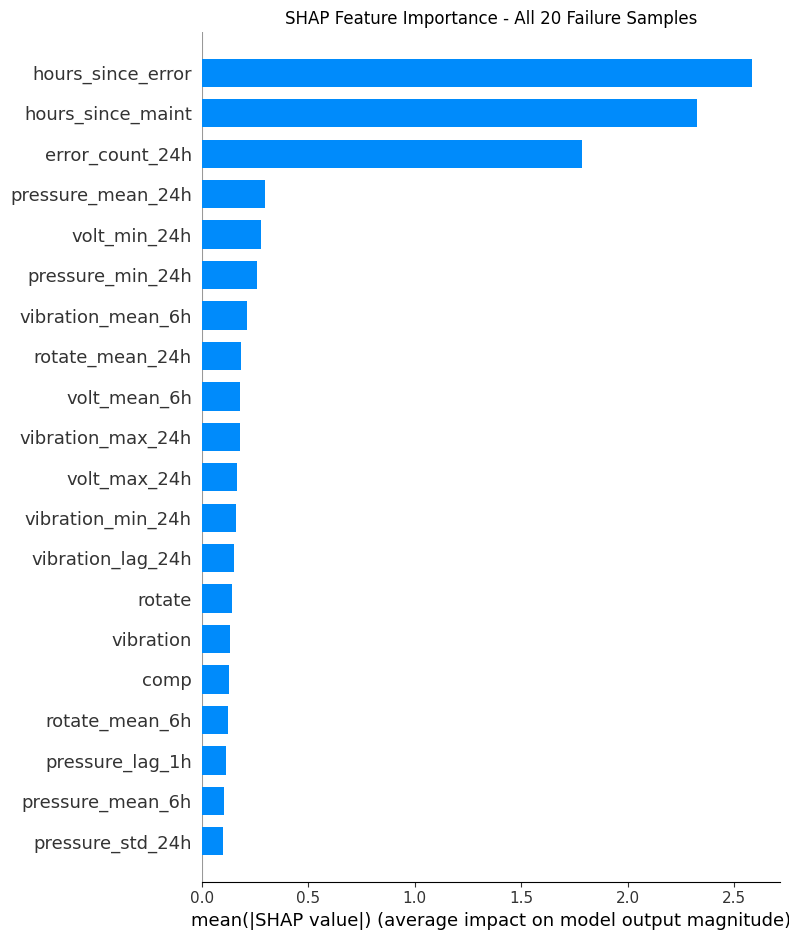

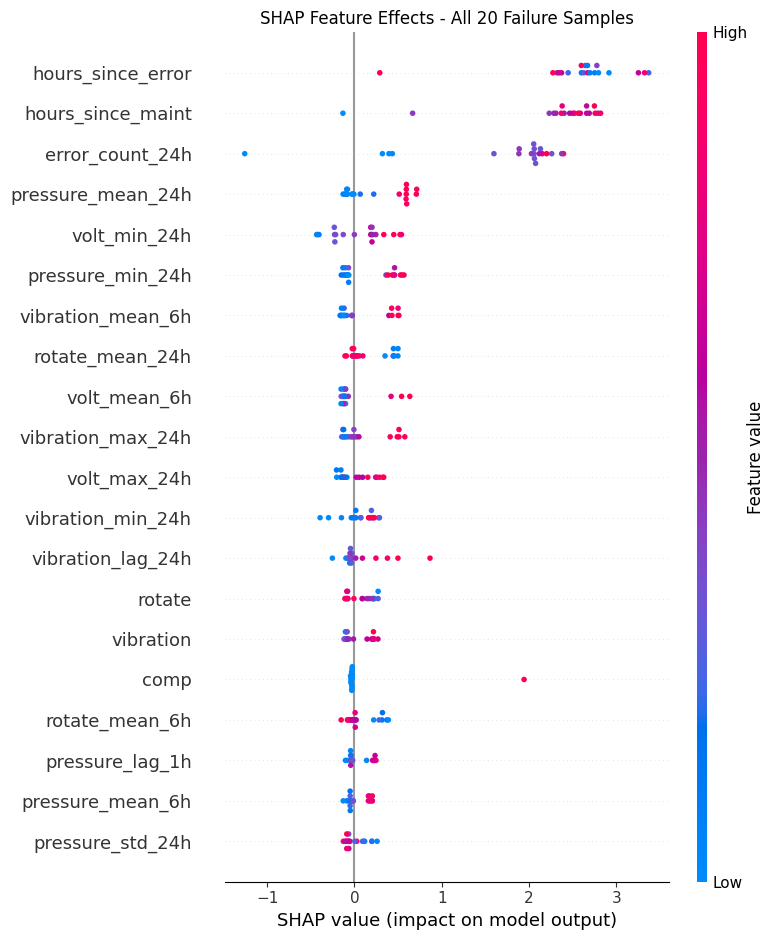


📊 PREDICTION SUMMARY FOR ALL SAMPLES:
--------------------------------------------------
Sample  1: Actual=1, Pred_Prob=0.9991, Pred_Class=1
Sample  2: Actual=1, Pred_Prob=0.9998, Pred_Class=1
Sample  3: Actual=1, Pred_Prob=0.9996, Pred_Class=1
Sample  4: Actual=1, Pred_Prob=0.9989, Pred_Class=1
Sample  5: Actual=1, Pred_Prob=0.9989, Pred_Class=1
Sample  6: Actual=1, Pred_Prob=0.9961, Pred_Class=1
Sample  7: Actual=1, Pred_Prob=0.9996, Pred_Class=1
Sample  8: Actual=1, Pred_Prob=0.9967, Pred_Class=1
Sample  9: Actual=1, Pred_Prob=0.9996, Pred_Class=1
Sample 10: Actual=1, Pred_Prob=0.9993, Pred_Class=1
Sample 11: Actual=1, Pred_Prob=0.9993, Pred_Class=1
Sample 12: Actual=1, Pred_Prob=0.9996, Pred_Class=1
Sample 13: Actual=1, Pred_Prob=0.9990, Pred_Class=1
Sample 14: Actual=1, Pred_Prob=0.9997, Pred_Class=1
Sample 15: Actual=1, Pred_Prob=0.9982, Pred_Class=1
Sample 16: Actual=1, Pred_Prob=0.9973, Pred_Class=1
Sample 17: Actual=1, Pred_Prob=0.9995, Pred_Class=1
Sample 18: Actual=1, Pred_

In [ ]:

# Example 1: Get failure samples and analyze them all together
print("🔥 EXAMPLE 1: Analyzing All Failure Samples Together")
print("=" * 50)

# Extract failure samples
failure_samples = get_failure_samples(
    df=df_with_lags, 
    target_col='target', 
    n_samples=20, 
    sample_type='random'
)

display(failure_samples)

if len(failure_samples) > 0:
    print(f"\n🔬 Calculating SHAP for all {len(failure_samples)} samples at once...")
    
    # Get best model from previous analysis
    best_model_name = results_summary.loc[results_summary['AUC'].idxmax(), 'Model']
    print(f"🤖 Using best performing model: {best_model_name}")
    
    # Prepare features
    exclude_cols = ['datetime', 'machineID', 'failure', 'binary_failure', 'target']
    feature_cols = [col for col in failure_samples.columns if col not in exclude_cols]
    X_samples = failure_samples[feature_cols].fillna(0)
    y_samples = failure_samples['target']
    
    # Use full training data
    X_train = df_with_lags[feature_cols].fillna(0)
    y_train = df_with_lags['target']
    
    # Configure and train the best model
    if best_model_name == 'CatBoost':
        pos_weight = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1
        model = CatBoostClassifier(
            iterations=100, depth=6, learning_rate=0.1,
            class_weights=[1, pos_weight], random_state=42,
            verbose=False, allow_writing_files=False
        )
    # Add other model configurations if needed...
    
    # Train model
    model.fit(X_train, y_train)
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)
    
    # Calculate SHAP values for ALL samples at once
    print(f"⚡ Calculating SHAP values for all {len(X_samples)} samples...")
    shap_values = explainer.shap_values(X_samples)
    
    # Handle different SHAP output formats
    if isinstance(shap_values, list):
        shap_values_binary = shap_values[1]  # Use positive class
    else:
        shap_values_binary = shap_values
    
    print(f"✅ SHAP values calculated! Shape: {shap_values_binary.shape}")
    
    # Get predictions for all samples
    sample_predictions = model.predict_proba(X_samples)[:, 1]
    sample_classes = model.predict(X_samples)
    
    # Global feature importance across all samples
    mean_abs_shap = np.abs(shap_values_binary).mean(axis=0)
    feature_importance_all = pd.DataFrame({
        'feature': feature_cols,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)
    
    print(f"\n🏆 Top 15 Most Important Features (across all {len(failure_samples)} samples):")
    print(feature_importance_all.head(15).to_string(index=False))
    
    # Summary plot for all samples
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_binary, X_samples, plot_type="bar", show=False, max_display=20)
    plt.title(f'SHAP Feature Importance - All {len(failure_samples)} Failure Samples')
    plt.tight_layout()
    plt.show()
    
    # Feature effects plot
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values_binary, X_samples, show=False, max_display=20)
    plt.title(f'SHAP Feature Effects - All {len(failure_samples)} Failure Samples')
    plt.tight_layout()
    plt.show()
    
    # Show individual predictions summary
    print(f"\n📊 PREDICTION SUMMARY FOR ALL SAMPLES:")
    print("-" * 50)
    for i, (actual, pred_prob, pred_class) in enumerate(zip(y_samples, sample_predictions, sample_classes)):
        print(f"Sample {i+1:2d}: Actual={actual}, Pred_Prob={pred_prob:.4f}, Pred_Class={pred_class}")
    
    # Feature type analysis across all samples
    print(f"\n🔍 FEATURE TYPE ANALYSIS (All {len(failure_samples)} samples):")
    lag_features = feature_importance_all[feature_importance_all['feature'].str.contains('_lag_')]
    rolling_features = feature_importance_all[feature_importance_all['feature'].str.contains('_mean_|_std_|_min_|_max_')]
    count_features = feature_importance_all[feature_importance_all['feature'].str.contains('_count_')]
    time_features = feature_importance_all[feature_importance_all['feature'].str.contains('hour|day_of_week|weekend|working')]
    original_features = feature_importance_all[
        ~feature_importance_all['feature'].str.contains('_lag_|_mean_|_std_|_min_|_max_|_count_|hour|day_of_week|weekend|working')
    ]
    
    feature_type_importance = {
        'Lag Features': lag_features['mean_abs_shap'].sum(),
        'Rolling Statistics': rolling_features['mean_abs_shap'].sum(),
        'Count Features': count_features['mean_abs_shap'].sum(),
        'Time Features': time_features['mean_abs_shap'].sum(),
        'Original Features': original_features['mean_abs_shap'].sum()
    }
    
    print("Feature Type Contributions:")
    for feature_type, importance in sorted(feature_type_importance.items(), key=lambda x: x[1], reverse=True):
        if importance > 0:
            print(f"  {feature_type}: {importance:.4f}")
    
    # Store results for later use
    batch_shap_results = {
        'model_name': best_model_name,
        'shap_values': shap_values_binary,
        'feature_importance': feature_importance_all,
        'feature_type_importance': feature_type_importance,
        'X_samples': X_samples,
        'y_samples': y_samples,
        'predictions': sample_predictions,
        'explainer': explainer,
        'model': model
    }
    
    print(f"\n✅ BATCH SHAP ANALYSIS COMPLETE!")
    print(f"   Model: {best_model_name}")
    print(f"   Samples analyzed: {len(failure_samples)}")
    print(f"   Most important feature: {feature_importance_all.iloc[0]['feature']}")
    
else:
    print("❌ No failure samples available for analysis")

,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,binary_failure,target,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
5368,2015-08-12 09:00:00,0.807091,0.632492,0.326726,0.592362,0,0,0,0,1,...,1.0,1.0,0.0,0.0,9,2,0,1,339,3


🔍 SHAP ANALYSIS FOR FAILURE SAMPLES
📊 Analyzing 1 sample(s)
🎯 Target column: 'target'
📈 Top 10 features requested
🤖 Using best performing model: CatBoost
📋 Using 62 features for analysis
   Sample target values: [1]
📚 Using full training dataset: 8,757 samples

🔧 Configuring CatBoost model...
🏋️ Training model...
🎯 Sample predictions:
   Sample 1: Actual=1, Predicted_Prob=0.9958, Predicted_Class=1

🔬 Creating SHAP explainer...
⚡ Calculating SHAP values for 1 sample(s)...
✅ SHAP values calculated successfully!
   SHAP values shape: (1, 62)

📊 ANALYSIS FOR SAMPLE 1
------------------------------
🏆 Top 10 Most Important Features:
          feature  shap_value  feature_value
hours_since_error    3.289340       3.000000
hours_since_maint    2.292128     339.000000
     volt_min_24h    0.461544       0.383840
     volt_max_24h    0.381714       0.833962
  error_count_24h    0.332834       1.000000
     volt_mean_6h    0.323331       0.616568
        vibration    0.147448       0.592362
 pres

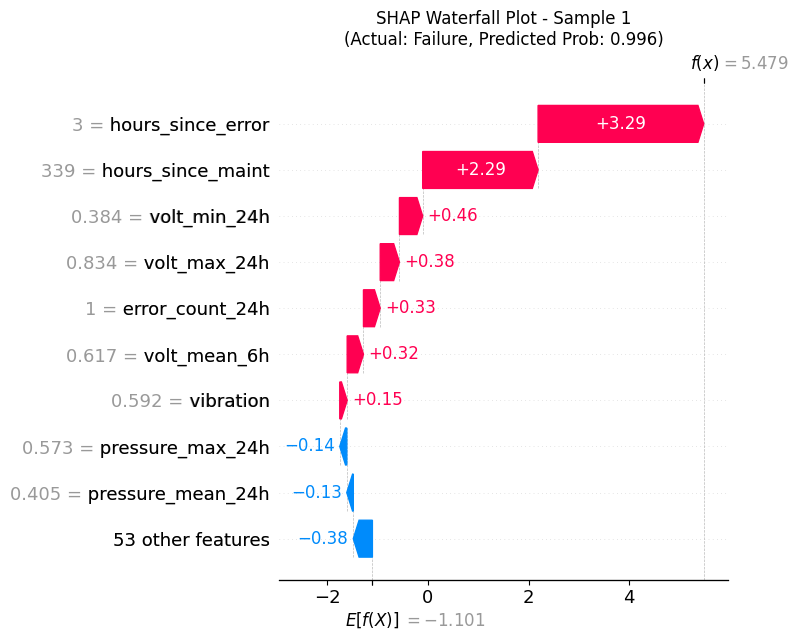

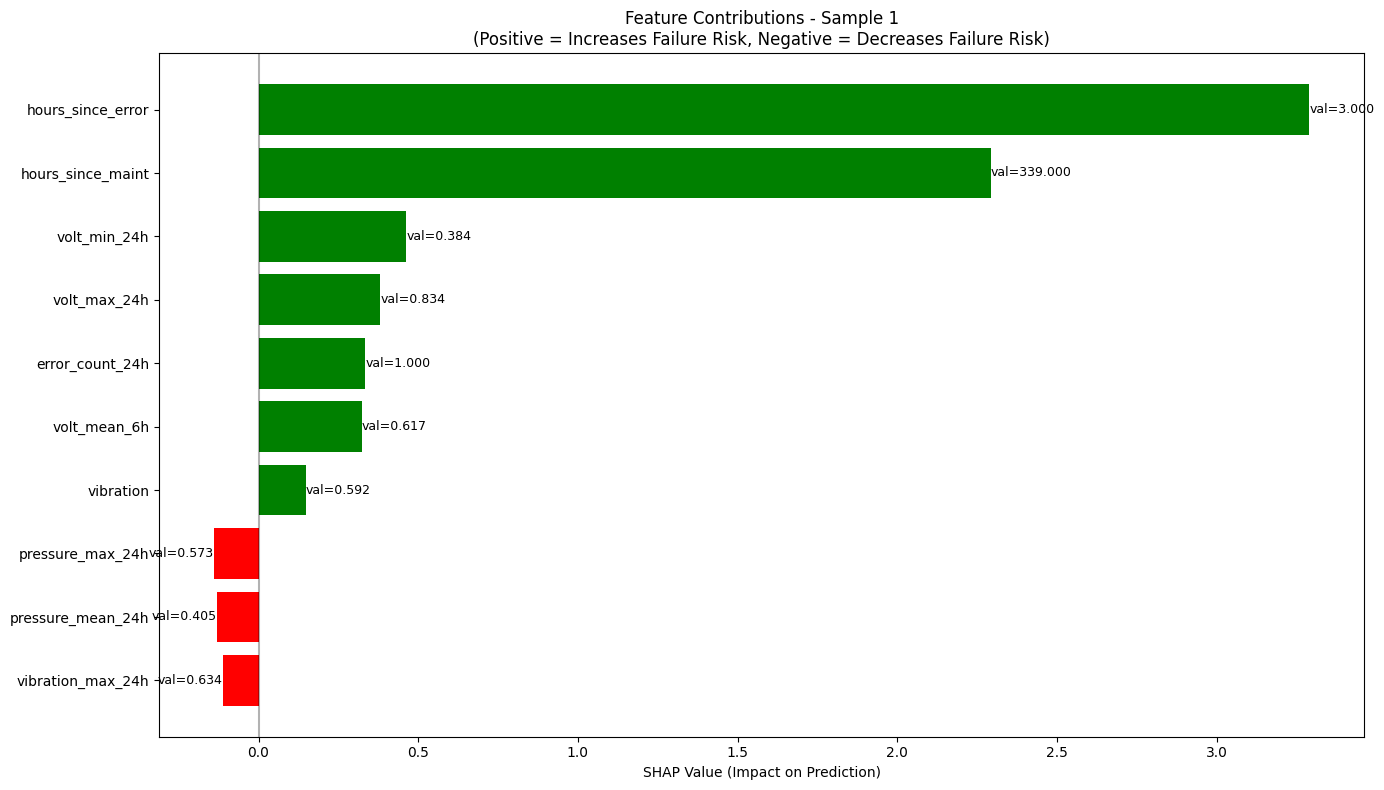


🔍 Feature Type Analysis for Sample 1:
   Feature Type Contributions:
     Time Features: 5.5815
     Rolling Statistics: 1.5481
     Count Features: 0.3328
     Original Features: 0.1474


In [34]:
## Example 2: Analyze a Single Specific Row

random_failure_sample = df_with_lags[df_with_lags["target"] == 1].sample(n=1)
display(random_failure_sample)

# Analyze this specific sample
specific_analysis = analyze_failure_samples_with_shap(
    sample_df=random_failure_sample,
    target_col='target',
    top_n_features=10)
